# Activity Cliff 예측 파이프라인

구조가 **한 군데만 다른 두 분자**의 약효 차이(Δ)를 예측한다.
약효가 크게 차이 나는 쌍(|Δ| ≥ 1, **cliff**)을 잘 맞히는 것이 목표다.

In [1]:
import os, urllib.request
from multiprocessing import Pool
import numpy as np, pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFMCS, rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')

DATA, PAIRS = 'data/moleculeace', 'data/pairs'
# 개발용: 작고 cliff 비율 높은 타깃 4개 (Ki 2 + EC50 2). 괜찮으면 30개로 늘린다
# CHEMBL2835_Ki는 쌍은 많지만 cliff 2%라 제외
DEV_TARGETS = ['CHEMBL1862_Ki', 'CHEMBL237_EC50', 'CHEMBL4616_EC50', 'CHEMBL2034_Ki']
USE_ALL_TARGETS = True  # True면 3번 셀에서 30개 전체로 바꾼다
SEED = 0
SEEDS = [0, 1, 2]       # 실행 간 편차를 재려면 시드가 여러 개여야 한다
SPLITS = ['train', 'val', 'test']   # 쌍 split. 모든 쌍은 학습 분자를 하나 이상 포함한다
CLIFF = 1.0         # |Δ| >= 1 → cliff (MoleculeACE 기준, 10배)
VAL_FRAC = 0.2      # train 분자 중 validation 비율
SIM_MIN = 0.5       # ECFP4 Tanimoto 사전 필터 (MCS 통과 쌍의 99.5% 유지)
MAX_CHANGED = 10    # 한쪽에서 바뀐 원자 수 상한 (MMP 관례)
MCS_TIMEOUT = 1     # 초. 2초로 늘려도 통과 쌍 거의 같음
EXPAND_TRAIN = True # 유사 쌍 전부 설정도 만든다 (4-1). 학습과 평가를 같은 종류로 맞춘다
N_JOBS = 64
os.makedirs(DATA, exist_ok=True); os.makedirs(PAIRS, exist_ok=True)

import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'Noto Sans CJK JP', 'axes.unicode_minus': False, 'figure.dpi': 110,
                     'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6, 'axes.axisbelow': True})
# 검증된 기본 categorical 팔레트의 앞 네 칸 (파랑 / 주황 / 아쿠아 / 노랑)
C1, C2, C3, C4 = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
SURFACE, MUTED = 'white', '0.45'

def tidy(a):
    """축을 눈에 덜 띄게"""
    a.spines[['top', 'right']].set_visible(False)
    a.spines[['left', 'bottom']].set_color('0.7')
    a.tick_params(colors='0.35', length=3)

## 1. 데이터

MoleculeACE의 30개 단백질 타깃 데이터를 내려받는다.

In [2]:
URL = 'https://raw.githubusercontent.com/molML/MoleculeACE/main/MoleculeACE/Data/benchmark_data/'
TARGETS = ['CHEMBL1862_Ki', 'CHEMBL1871_Ki', 'CHEMBL2034_Ki', 'CHEMBL2047_EC50', 'CHEMBL204_Ki', 'CHEMBL2147_Ki',
           'CHEMBL214_Ki', 'CHEMBL218_EC50', 'CHEMBL219_Ki', 'CHEMBL228_Ki', 'CHEMBL231_Ki', 'CHEMBL233_Ki',
           'CHEMBL234_Ki', 'CHEMBL235_EC50', 'CHEMBL236_Ki', 'CHEMBL237_EC50', 'CHEMBL237_Ki', 'CHEMBL238_Ki',
           'CHEMBL239_EC50', 'CHEMBL244_Ki', 'CHEMBL262_Ki', 'CHEMBL264_Ki', 'CHEMBL2835_Ki', 'CHEMBL287_Ki',
           'CHEMBL2971_Ki', 'CHEMBL3979_EC50', 'CHEMBL4005_Ki', 'CHEMBL4203_Ki', 'CHEMBL4616_EC50', 'CHEMBL4792_Ki']
for t in TARGETS:
    if not os.path.exists(f'{DATA}/{t}.csv'):
        urllib.request.urlretrieve(f'{URL}{t}.csv', f'{DATA}/{t}.csv')
if USE_ALL_TARGETS:
    DEV_TARGETS = TARGETS
print(f'사용 타깃 {len(DEV_TARGETS)}개')

사용 타깃 30개


## 2. 분자 나누기

분자를 **학습 / 검증 / 평가**용으로 나눈다. 쌍은 **한쪽이 반드시 학습 분자**가 되도록 쓴다.

- **학습 쌍**: 학습 분자 – 학습 분자
- **검증 쌍**: 검증 분자 – 학습 분자
- **평가 쌍**: 평가 분자 – 학습 분자

두 분자 모두 처음 보는 쌍(검증–검증, 평가–평가)은 쓰지 않는다.
실측값을 아는 기준 분자 없이 Δ만 맞히면, 두 분자의 활성을 똑같이 틀려도 정답으로 처리될 수 있기 때문이다.
(이런 쌍도 쌍 캐시에는 남겨 둔다)

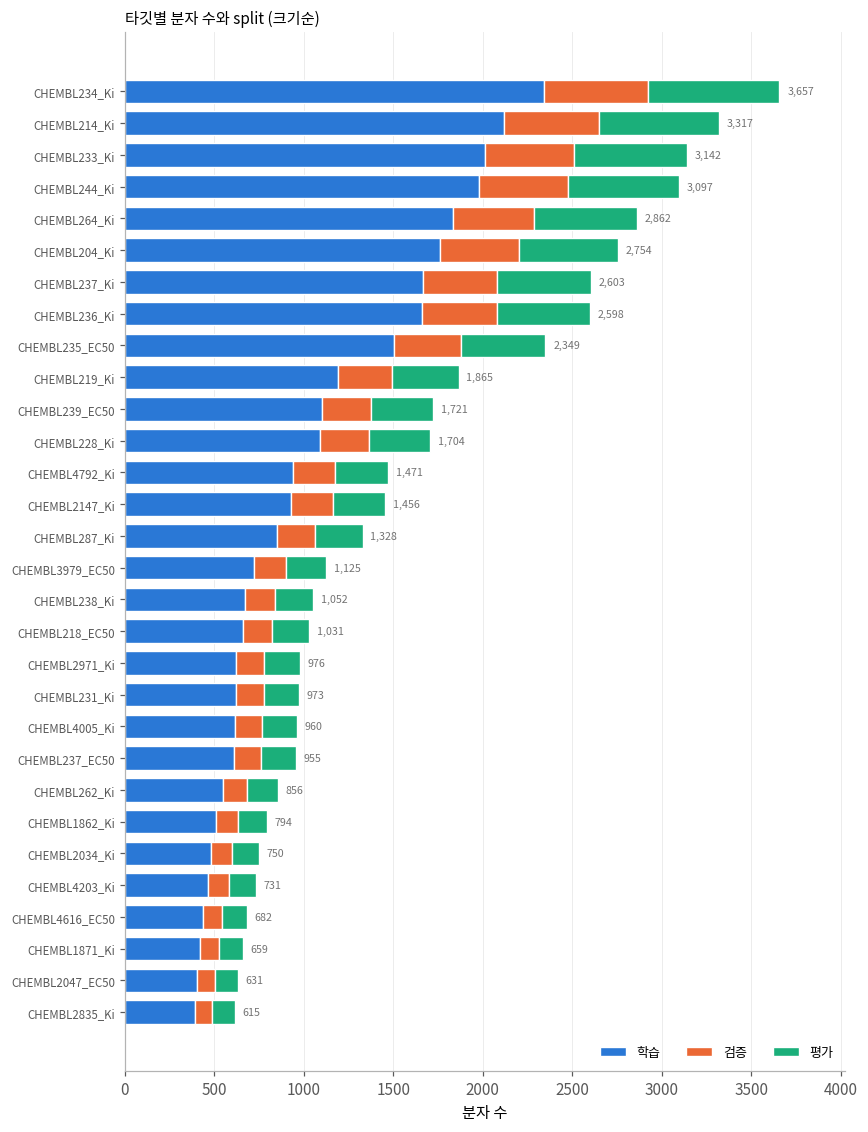

분자 48,714행 | train 31,144 (64%)  val 7,768 (16%)  test 9,802 (20%) | 타깃당 615~3,657개


In [3]:
from functools import lru_cache

@lru_cache(maxsize=None)   # 30개 타깃이면 load가 수십 번 불린다
def load(target):
    df = pd.read_csv(f'{DATA}/{target}.csv').rename(columns={'y [pEC50/pKi]': 'p'})[['smiles', 'p', 'cliff_mol', 'split']]
    train = df.index[df.split == 'train']
    rng = np.random.default_rng(SEED)
    # ponytail: 단순 무작위 추출. val 결과가 흔들리면 cliff_mol 기준 층화 추출로 바꾼다
    df.loc[rng.choice(train, int(len(train) * VAL_FRAC), replace=False), 'split'] = 'val'
    return df

sp = pd.DataFrame({t: load(t).split.value_counts() for t in DEV_TARGETS}).T[['train', 'val', 'test']]
sp = sp.loc[sp.sum(1).sort_values().index]

fig, a_ = plt.subplots(figsize=(8, 0.30 * len(sp) + 1.4))
y, left = np.arange(len(sp)), np.zeros(len(sp))
for col, c, lbl in [('train', C1, '학습'), ('val', C2, '검증'), ('test', C3, '평가')]:
    a_.barh(y, sp[col], 0.74, left=left, color=c, label=lbl, zorder=2,
            edgecolor=SURFACE, linewidth=0.9)   # 흰 테두리로 구간을 떼어 놓는다
    left += sp[col].values
for i, v in enumerate(left):
    a_.text(v + left.max() * 0.012, i, f'{int(v):,}', va='center', fontsize=7, color=MUTED)

a_.set(yticks=y, xlabel='분자 수', xlim=(0, left.max() * 1.10))
a_.set_yticklabels(sp.index, fontsize=7.5)
a_.legend(fontsize=8.5, frameon=False, ncol=3, loc='lower right')
a_.grid(axis='y', visible=False); tidy(a_)
a_.set_title('타깃별 분자 수와 split (크기순)', loc='left', fontsize=10)
fig.tight_layout(); plt.show()

tot = sp.sum()
print(f'분자 {int(tot.sum()):,}행 | ' + '  '.join(f'{k} {int(v):,} ({v/tot.sum():.0%})' for k, v in tot.items())
      + f' | 타깃당 {int(sp.sum(1).min()):,}~{int(sp.sum(1).max()):,}개')

## 3. "한 군데만 다른 쌍" 정하기

두 분자에서 **공통 부분을 찾고, 나머지를 바뀐 부분**으로 본다.
바뀐 부분이 **한 덩어리이고 작을 때만** 쌍으로 인정한다.
아래 그림에서 빨간 원자가 바뀐 부분이다.

In [4]:
def n_components(mol, atoms):
    left, n = set(atoms), 0
    while left:
        n += 1
        stack = [left.pop()]
        while stack:
            for nb in mol.GetAtomWithIdx(stack.pop()).GetNeighbors():
                if nb.GetIdx() in left:
                    left.remove(nb.GetIdx()); stack.append(nb.GetIdx())
    return n

def anchors(mol, changed, match):
    """바뀐 원자에 붙은 MCS 원자를 MCS 쿼리 내 순번으로 반환"""
    pos = {x: k for k, x in enumerate(match)}
    return {pos[nb.GetIdx()] for a in changed for nb in mol.GetAtomWithIdx(a).GetNeighbors() if nb.GetIdx() in pos}

def single_site(sa, sb):
    """한 곳만 다르면 (edit, atoms_a, atoms_b), 아니면 탈락 사유 문자열"""
    a, b = Chem.MolFromSmiles(sa), Chem.MolFromSmiles(sb)
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    if r.canceled:
        return 'timeout'
    q = Chem.MolFromSmarts(r.smartsString)
    ma = a.GetSubstructMatch(q)
    ca = [i for i in range(a.GetNumAtoms()) if i not in ma]
    # 대칭 분자는 매칭이 여러 개라 anchor 순번이 달라질 수 있어 B의 매칭을 모두 확인
    for mb in b.GetSubstructMatches(q, uniquify=False, maxMatches=1000):
        cb = [i for i in range(b.GetNumAtoms()) if i not in mb]
        if not ca and not cb:
            return 'identical_2d'
        if max(len(ca), len(cb)) > MAX_CHANGED:
            return 'too_big'
        if n_components(a, ca) > 1 or n_components(b, cb) > 1:
            continue
        if not ca or not cb or anchors(a, ca, ma) == anchors(b, cb, mb):
            return ('insert' if not ca else 'delete' if not cb else 'replace'), ca, cb
    return 'multi_site'

In [5]:
# 판정 규칙 확인
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(N)cc1')[0] == 'replace'  # 치환기 교체
assert single_site('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(F)cc1')[0] == 'insert'      # H → F
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccccc1')[0] == 'delete'      # F → H
assert single_site('Cc1ccccc1', 'Cc1ccncc1')[0] == 'replace'                     # 고리 원자 C → N
assert single_site('Fc1ccc(Cl)cc1', 'Nc1ccc(Br)cc1') == 'multi_site'             # 두 곳 변경
assert single_site('C[C@H](N)O', 'C[C@@H](N)O') == 'identical_2d'                # 입체만 다름
assert single_site('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(OCCCCCCCCCCCC)cc1') == 'too_big'  # 13원자
print('판정 규칙 확인 완료')

판정 규칙 확인 완료


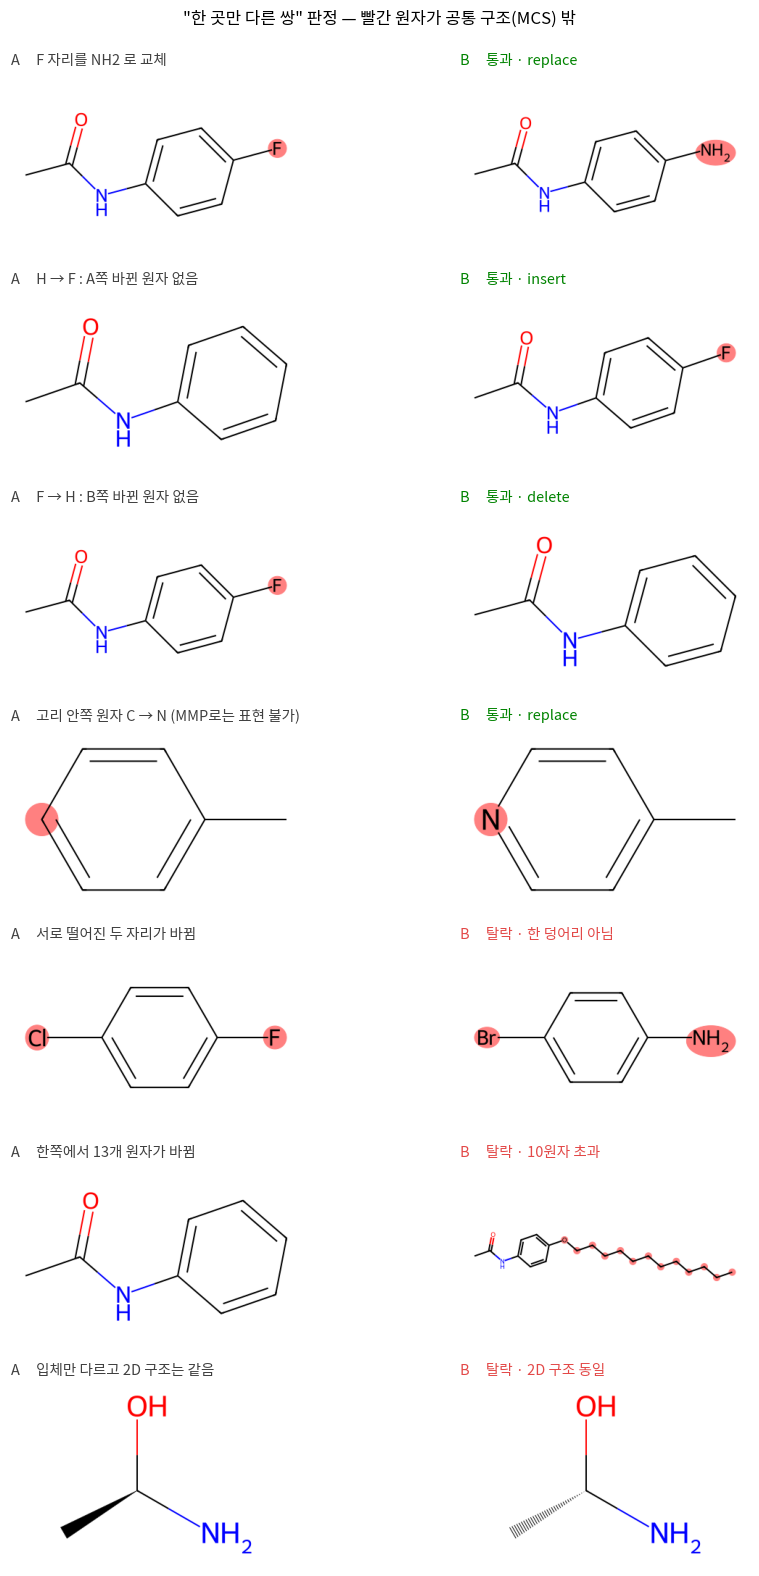

In [6]:
import io
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

RULE_CASES = [
    ('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(N)cc1', 'F 자리를 NH2 로 교체'),
    ('CC(=O)Nc1ccccc1',    'CC(=O)Nc1ccc(F)cc1', 'H → F : A쪽 바뀐 원자 없음'),
    ('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccccc1',    'F → H : B쪽 바뀐 원자 없음'),
    ('Cc1ccccc1',          'Cc1ccncc1',          '고리 안쪽 원자 C → N (MMP로는 표현 불가)'),
    ('Fc1ccc(Cl)cc1',      'Nc1ccc(Br)cc1',      '서로 떨어진 두 자리가 바뀜'),
    ('CC(=O)Nc1ccccc1',    'CC(=O)Nc1ccc(OCCCCCCCCCCCC)cc1', '한쪽에서 13개 원자가 바뀜'),
    ('C[C@H](N)O',         'C[C@@H](N)O',        '입체만 다르고 2D 구조는 같음'),
]
VERDICT = {'replace': '통과 · replace', 'insert': '통과 · insert', 'delete': '통과 · delete',
           'multi_site': '탈락 · 한 덩어리 아님', 'too_big': f'탈락 · {MAX_CHANGED}원자 초과',
           'identical_2d': '탈락 · 2D 구조 동일'}
PASS, FAIL = '#008300', '#e34948'

def mcs_diff(a, b):
    """판정 통과 여부와 무관하게 MCS 밖 원자를 구한다 (그림 전용)"""
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    q = Chem.MolFromSmarts(r.smartsString)
    ma, mb = a.GetSubstructMatch(q), b.GetSubstructMatch(q)
    return q, [i for i in range(a.GetNumAtoms()) if i not in ma], [i for i in range(b.GetNumAtoms()) if i not in mb]

def render(m, hl):
    """RDKit으로 분자만 그린다. 글자는 matplotlib이 얹는다 (RDKit 폰트에 한글이 없다)"""
    d = rdMolDraw2D.MolDraw2DCairo(400, 250)
    rdMolDraw2D.PrepareAndDrawMolecule(d, m, highlightAtoms=hl)
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig, axes = plt.subplots(len(RULE_CASES), 2, figsize=(9.5, 2.05 * len(RULE_CASES)))
for (sa, sb, note), (ax_a, ax_b) in zip(RULE_CASES, axes):
    a, b = Chem.MolFromSmiles(sa), Chem.MolFromSmiles(sb)
    rdDepictor.Compute2DCoords(a)
    q, ca, cb = mcs_diff(a, b)
    rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=q, acceptFailure=True)
    res = single_site(sa, sb)
    key = res if isinstance(res, str) else res[0]
    ax_a.imshow(render(a, ca)); ax_b.imshow(render(b, cb))
    ax_a.set_title(f'A     {note}', loc='left', fontsize=9.5, color='0.25')
    ax_b.set_title(f'B     {VERDICT[key]}', loc='left', fontsize=9.5,
                   color=PASS if key in ('replace', 'insert', 'delete') else FAIL)
    for x in (ax_a, ax_b): x.axis('off')
fig.suptitle('"한 곳만 다른 쌍" 판정 — 빨간 원자가 공통 구조(MCS) 밖', y=0.995, fontsize=11)
fig.tight_layout(); plt.show()

## 4. 쌍 만들기

같은 타깃 안에서 서로 비슷한 분자끼리 짝을 짓고, 3번 규칙을 통과한 것만 남긴다.

In [7]:
FPGEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
PAIR_SPLIT = {('train', 'train'): 'train', ('train', 'val'): 'val_easy', ('val', 'val'): 'val_hard',
              ('test', 'train'): 'test_easy', ('test', 'test'): 'test_hard'}

def _job(args):
    i, j, sa, sb = args
    try:
        return i, j, single_site(sa, sb)
    except Exception:
        return i, j, 'error'

def make_pairs(target):
    path = f'{PAIRS}/{target}.pkl'
    if os.path.exists(path):
        cached = pd.read_pickle(path)
        return cached
    df = load(target)
    fps = [FPGEN.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
    cand = [(i, j) for i in range(len(df))
            for j, s in enumerate(DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:]), i + 1) if s >= SIM_MIN]
    cand = [(i, j) for i, j in cand if tuple(sorted((df.split[i], df.split[j]))) in PAIR_SPLIT]
    with Pool(N_JOBS) as pool:
        res = pool.map(_job, [(i, j, df.smiles[i], df.smiles[j]) for i, j in cand], chunksize=20)

    rows = []
    for i, j, r in res:
        if isinstance(r, str):
            continue
        edit, ca, cb = r
        a, b = Chem.MolFromSmiles(df.smiles[i]), Chem.MolFromSmiles(df.smiles[j])
        rows.append(dict(i=i, j=j, smiles_a=df.smiles[i], smiles_b=df.smiles[j], p_a=df.p[i], p_b=df.p[j],
                         delta=df.p[j] - df.p[i], edit=edit, atoms_a=ca, atoms_b=cb,
                         frag_a=Chem.MolFragmentToSmiles(a, ca) if ca else '',
                         frag_b=Chem.MolFragmentToSmiles(b, cb) if cb else '',
                         split=PAIR_SPLIT[tuple(sorted((df.split[i], df.split[j])))]))
    pairs = pd.DataFrame(rows)
    pairs['is_cliff'] = pairs.delta.abs() >= CLIFF
    pairs.to_pickle(path)
    return pairs

# 쌍 캐시에는 hard 쌍(검증–검증, 평가–평가)도 들어 있다. 파이프라인에서는 학습 분자를 포함한 쌍만 쓴다
KEEP = {'train': 'train', 'val_easy': 'val', 'test_easy': 'test'}
def keep_anchored(df):
    return df[df.split.isin(KEEP)].assign(split=lambda d: d.split.map(KEEP)).reset_index(drop=True)

pairs = keep_anchored(pd.concat([make_pairs(t).assign(target=t) for t in DEV_TARGETS], ignore_index=True))
# 각 분자가 속한 split (쌍 split의 근거)
mol_split = {t: load(t).split for t in DEV_TARGETS}
pairs['split_a'] = [mol_split[t][i] for t, i in zip(pairs.target, pairs.i)]
pairs['split_b'] = [mol_split[t][j] for t, j in zip(pairs.target, pairs.j)]
print(f'쌍 {len(pairs):,}개  |  cliff {pairs.is_cliff.sum():,}개 ({pairs.is_cliff.mean():.1%})')

쌍 143,507개  |  cliff 31,778개 (22.1%)


## 4-1. 유사 쌍 전부 (두 번째 설정)

한 군데만 다른 쌍만으로는 학습 데이터가 부족해서, **비슷하기만 하면 전부** 쓰는 설정을 하나 더 만든다.
처음에는 학습만 이걸로 하고 평가는 한 군데만 다른 쌍으로 했는데, 둘의 성질이 달라 예측이 과장됐다.
그래서 지금은 **학습과 평가를 같은 종류로 맞춘 두 설정**을 따로 돌린다.


In [8]:
def sim_pairs(target):
    """유사도 조건만 만족하는 쌍 전부 (모든 split 조합). 공통 구조 계산이 없어 지문 비교만 하면 된다"""
    path = f'{PAIRS}/{target}_simall.pkl'
    if os.path.exists(path):
        return pd.read_pickle(path)
    df = load(target)
    fps = [FPGEN.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
    sp = df.split.values
    rows = []
    for i in range(len(df)):
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:]))
        for j in np.where(sims >= SIM_MIN)[0] + i + 1:
            key = tuple(sorted((sp[i], sp[j])))
            if key in PAIR_SPLIT:
                rows.append(dict(i=int(i), j=int(j), delta=df.p[j] - df.p[i], split=PAIR_SPLIT[key]))
    out = pd.DataFrame(rows)
    out.to_pickle(path)
    return out

# 한 군데만 다른 쌍의 편집 정보를 유사 쌍 표에 옮겨 붙인다
info = pairs.set_index(['target', 'i', 'j'])[['edit', 'atoms_a', 'atoms_b']]
pairs_all = keep_anchored(pd.concat([sim_pairs(t).assign(target=t) for t in DEV_TARGETS], ignore_index=True)) \
              .join(info, on=['target', 'i', 'j'])
assert pairs_all.edit.notna().sum() == len(info), '한 군데만 다른 쌍은 모두 유사 쌍 안에 있어야 한다'
pairs_all['edit'] = pairs_all.edit.fillna('multi')
pairs_all[['atoms_a', 'atoms_b']] = pairs_all[['atoms_a', 'atoms_b']].map(lambda v: v if isinstance(v, list) else [])
pairs_all['is_cliff'] = pairs_all.delta.abs() >= CLIFF

# 두 가지 설정. 학습과 평가를 같은 종류의 쌍으로 맞춘다
PAIRSETS = {'single': pairs, 'all': pairs_all}

summary = pd.DataFrame({
    '한 군데만 다른 쌍': {'학습': int((pairs.split == 'train').sum()),
                   '평가(val+test)': int((pairs.split != 'train').sum()),
                   'cliff 비율': f'{pairs.is_cliff.mean():.1%}'},
    '유사 쌍 전부':     {'학습': int((pairs_all.split == 'train').sum()),
                   '평가(val+test)': int((pairs_all.split != 'train').sum()),
                   'cliff 비율': f'{pairs_all.is_cliff.mean():.1%}'}}).T
summary['배수'] = [1.0, round(len(pairs_all) / len(pairs), 1)]
summary

,학습,평가(val+test),cliff 비율,배수
한 군데만 다른 쌍,67509,75998,22.1%,1.0
유사 쌍 전부,349565,396137,27.7%,5.2


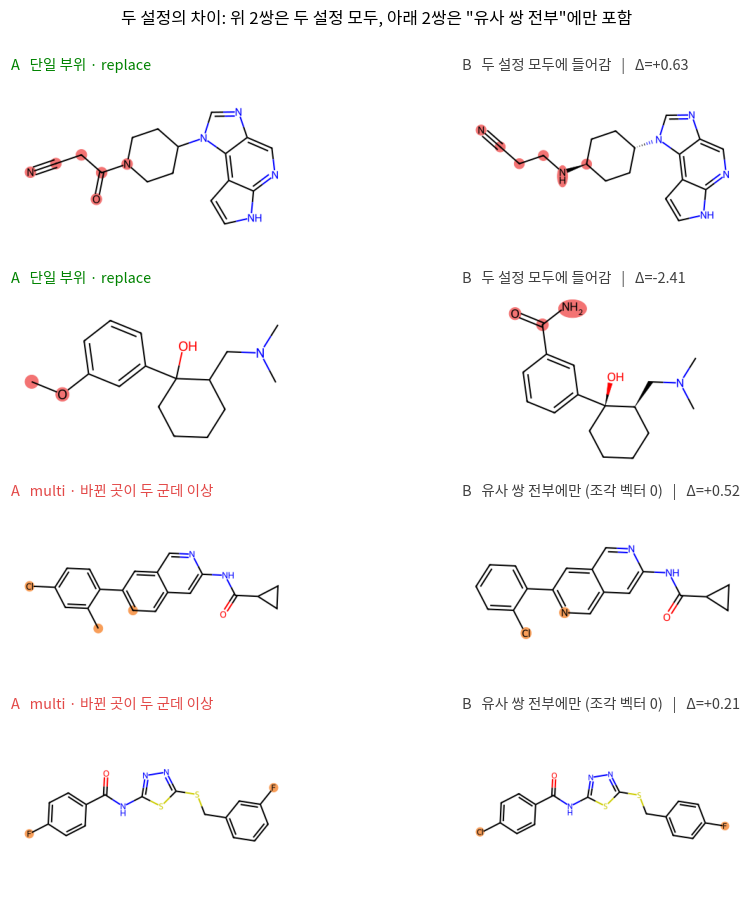

In [9]:
import io
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def _smi(t, k): return load(t).smiles[k]
def _nat(t, k): return Chem.MolFromSmiles(_smi(t, k)).GetNumAtoms()

def mcs_diff(a, b):
    """판정 통과 여부와 무관하게 공통 구조 밖 원자를 구한다 (그림 전용)"""
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    q = Chem.MolFromSmarts(r.smartsString)
    ma, mb = a.GetSubstructMatch(q), b.GetSubstructMatch(q)
    return q, [i for i in range(a.GetNumAtoms()) if i not in ma], [i for i in range(b.GetNumAtoms()) if i not in mb]

def render_mol(m, hl, color):
    """RDKit으로 분자만 그린다. 글자는 matplotlib이 얹는다 (RDKit 폰트에 한글이 없다)"""
    d = rdMolDraw2D.MolDraw2DCairo(400, 250)
    rdMolDraw2D.PrepareAndDrawMolecule(d, m, highlightAtoms=hl, highlightAtomColors={i: color for i in hl})
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

def _pick(sub, n, seed, want_multi):
    """작고 보기 좋은 예시만 고른다. multi는 바뀐 곳이 실제로 두 군데 이상인 것"""
    out = []
    for r in sub.sample(min(len(sub), 600), random_state=seed).itertuples():
        if max(_nat(r.target, r.i), _nat(r.target, r.j)) > 24:
            continue
        a, b = Chem.MolFromSmiles(_smi(r.target, r.i)), Chem.MolFromSmiles(_smi(r.target, r.j))
        _, ca, cb = mcs_diff(a, b)
        if not ca or not cb or max(len(ca), len(cb)) > 6:
            continue
        if (max(n_components(a, ca), n_components(b, cb)) >= 2) != want_multi:
            continue
        out.append(r)
        if len(out) == n:
            break
    return out

RED, ORANGE = (0.95, 0.45, 0.45), (0.97, 0.62, 0.35)
_tr = pairs_all[pairs_all.split == 'train']
rows = ([(r, 'single') for r in _pick(_tr[_tr.edit != 'multi'], 2, 1, False)]
        + [(r, 'multi') for r in _pick(_tr[_tr.edit == 'multi'], 2, 5, True)])

fig, axes = plt.subplots(len(rows), 2, figsize=(9.5, 2.05 * len(rows)))
for (r, kind), (ax_a, ax_b) in zip(rows, axes):
    a, b = Chem.MolFromSmiles(_smi(r.target, r.i)), Chem.MolFromSmiles(_smi(r.target, r.j))
    rdDepictor.Compute2DCoords(a)
    q, ca, cb = mcs_diff(a, b)
    rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=q, acceptFailure=True)
    col = RED if kind == 'single' else ORANGE
    ax_a.imshow(render_mol(a, ca, col)); ax_b.imshow(render_mol(b, cb, col))
    if kind == 'single':
        ax_a.set_title(f'A   단일 부위 · {r.edit}', loc='left', fontsize=9.5, color='#008300')
        ax_b.set_title(f'B   두 설정 모두에 들어감   |   Δ={r.delta:+.2f}', loc='left', fontsize=9.5, color='0.25')
    else:
        ax_a.set_title('A   multi · 바뀐 곳이 두 군데 이상', loc='left', fontsize=9.5, color='#e34948')
        ax_b.set_title(f'B   유사 쌍 전부에만 (조각 벡터 0)   |   Δ={r.delta:+.2f}', loc='left', fontsize=9.5, color='0.25')
    for x in (ax_a, ax_b):
        x.axis('off')
fig.suptitle('두 설정의 차이: 위 2쌍은 두 설정 모두, 아래 2쌍은 "유사 쌍 전부"에만 포함', y=0.997, fontsize=11)
fig.tight_layout(); plt.show()

## 5. 쌍 살펴보기

만들어진 쌍의 개수와 cliff 비율, 그리고 실제 예시를 본다.
cliff 쌍을 일부러 골라 넣지 않았다 — 쌍을 먼저 만들고 약효 차이는 나중에 확인했다.

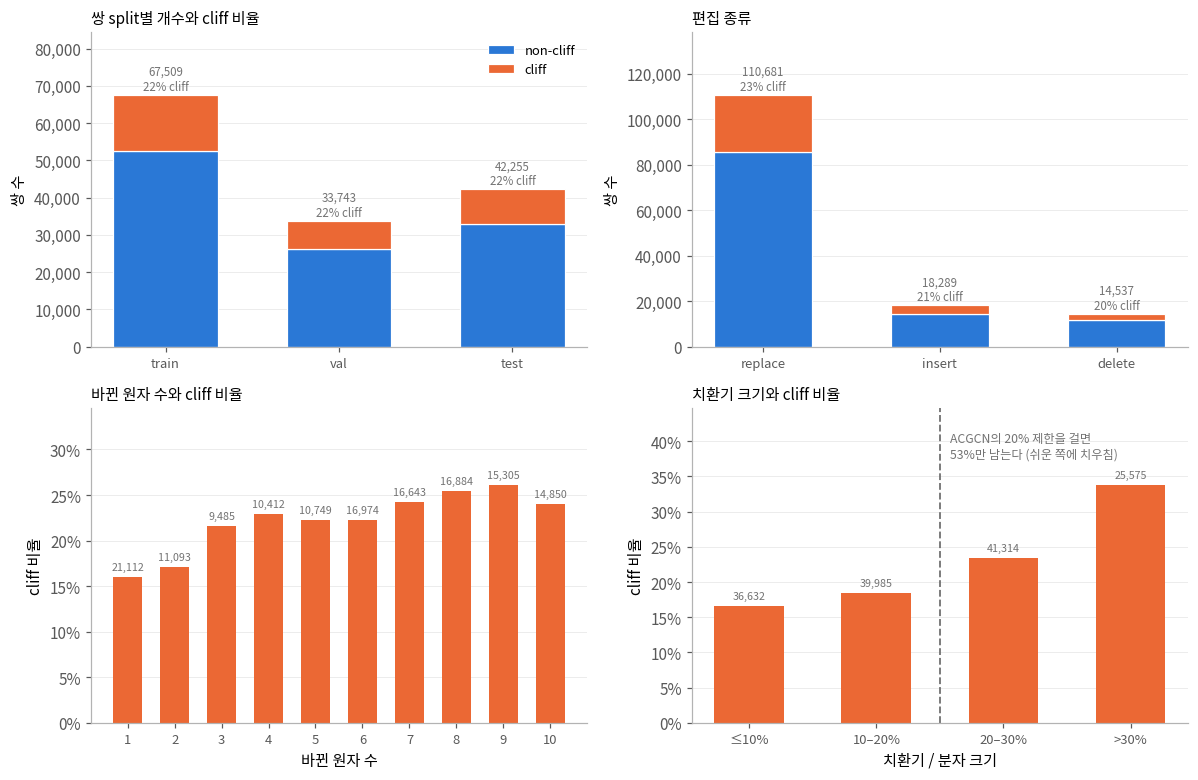

In [10]:
# 바뀐 원자 수와 "치환기 / 분자" 크기 비율 (ACGCN은 20% 이하인 쌍만 썼다)
n_heavy = {(t, k): Chem.MolFromSmiles(s).GetNumAtoms() for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
pairs['n_changed'] = pairs[['atoms_a', 'atoms_b']].map(len).max(axis=1)
pairs['size_ratio'] = pairs.n_changed / [min(n_heavy[t, i], n_heavy[t, j])
                                         for t, i, j in zip(pairs.target, pairs.i, pairs.j)]

fig, ax = plt.subplots(2, 2, figsize=(11, 7.2))
thousands = lambda v, _: f'{int(v):,}'

def stacked(a_, idx, nc, cl, width=0.6):
    x = np.arange(len(idx))
    a_.bar(x, nc, width, color=C1, label='non-cliff', zorder=2, edgecolor=SURFACE, linewidth=0.8)
    a_.bar(x, cl, width, bottom=nc, color=C2, label='cliff', zorder=2, edgecolor=SURFACE, linewidth=0.8)
    for i, (n, c) in enumerate(zip(nc, cl)):
        a_.text(i, n + c + (nc + cl).max() * 0.02, f'{n + c:,}\n{c / (n + c):.0%} cliff',
                ha='center', fontsize=7.5, color=MUTED)
    a_.set(xticks=x, ylabel='쌍 수', ylim=(0, (nc + cl).max() * 1.25))
    a_.set_xticklabels(idx, fontsize=8.5)
    a_.yaxis.set_major_formatter(thousands)

d = pairs.groupby(['split', 'is_cliff']).size().unstack(fill_value=0).reindex(SPLITS)
stacked(ax[0, 0], SPLITS, d[False].values, d[True].values)
ax[0, 0].legend(fontsize=8.5, frameon=False)
ax[0, 0].set_title('쌍 split별 개수와 cliff 비율', loc='left', fontsize=10)

e = pairs.groupby(['edit', 'is_cliff']).size().unstack(fill_value=0).sort_values(True, ascending=False)
stacked(ax[0, 1], e.index, e[False].values, e[True].values, 0.55)
ax[0, 1].set_title('편집 종류', loc='left', fontsize=10)

def ratio_bars(a_, g, xlabel, note=None, width=0.6):
    x = np.arange(len(g))
    a_.bar(x, g['mean'], width, color=C2, zorder=2)
    for i, (_, r) in enumerate(g.iterrows()):
        a_.text(i, r['mean'] + g['mean'].max() * 0.03, f'{int(r["size"]):,}', ha='center', fontsize=7, color=MUTED)
    a_.set(xticks=x, xlabel=xlabel, ylabel='cliff 비율', ylim=(0, g['mean'].max() * 1.32))
    a_.set_xticklabels(g.index, fontsize=8.5)
    a_.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')

ratio_bars(ax[1, 0], pairs.groupby('n_changed').is_cliff.agg(['size', 'mean']), '바뀐 원자 수')
ax[1, 0].set_title('바뀐 원자 수와 cliff 비율', loc='left', fontsize=10)

rb = pd.cut(pairs.size_ratio, [0, 0.1, 0.2, 0.3, 1.0], labels=['≤10%', '10–20%', '20–30%', '>30%'])
g = pairs.groupby(rb, observed=True).is_cliff.agg(['size', 'mean'])
ratio_bars(ax[1, 1], g, '치환기 / 분자 크기', width=0.55)
ax[1, 1].axvline(1.5, color=MUTED, ls='--', lw=1.2)
ax[1, 1].text(1.58, g['mean'].max() * 1.22, f'ACGCN의 20% 제한을 걸면\n{(pairs.size_ratio <= 0.2).mean():.0%}만 남는다 (쉬운 쪽에 치우침)',
              fontsize=8, color=MUTED, va='top')
ax[1, 1].set_title('치환기 크기와 cliff 비율', loc='left', fontsize=10)

for a_ in ax.ravel():
    tidy(a_); a_.grid(axis='x', visible=False)
fig.tight_layout(); plt.show()

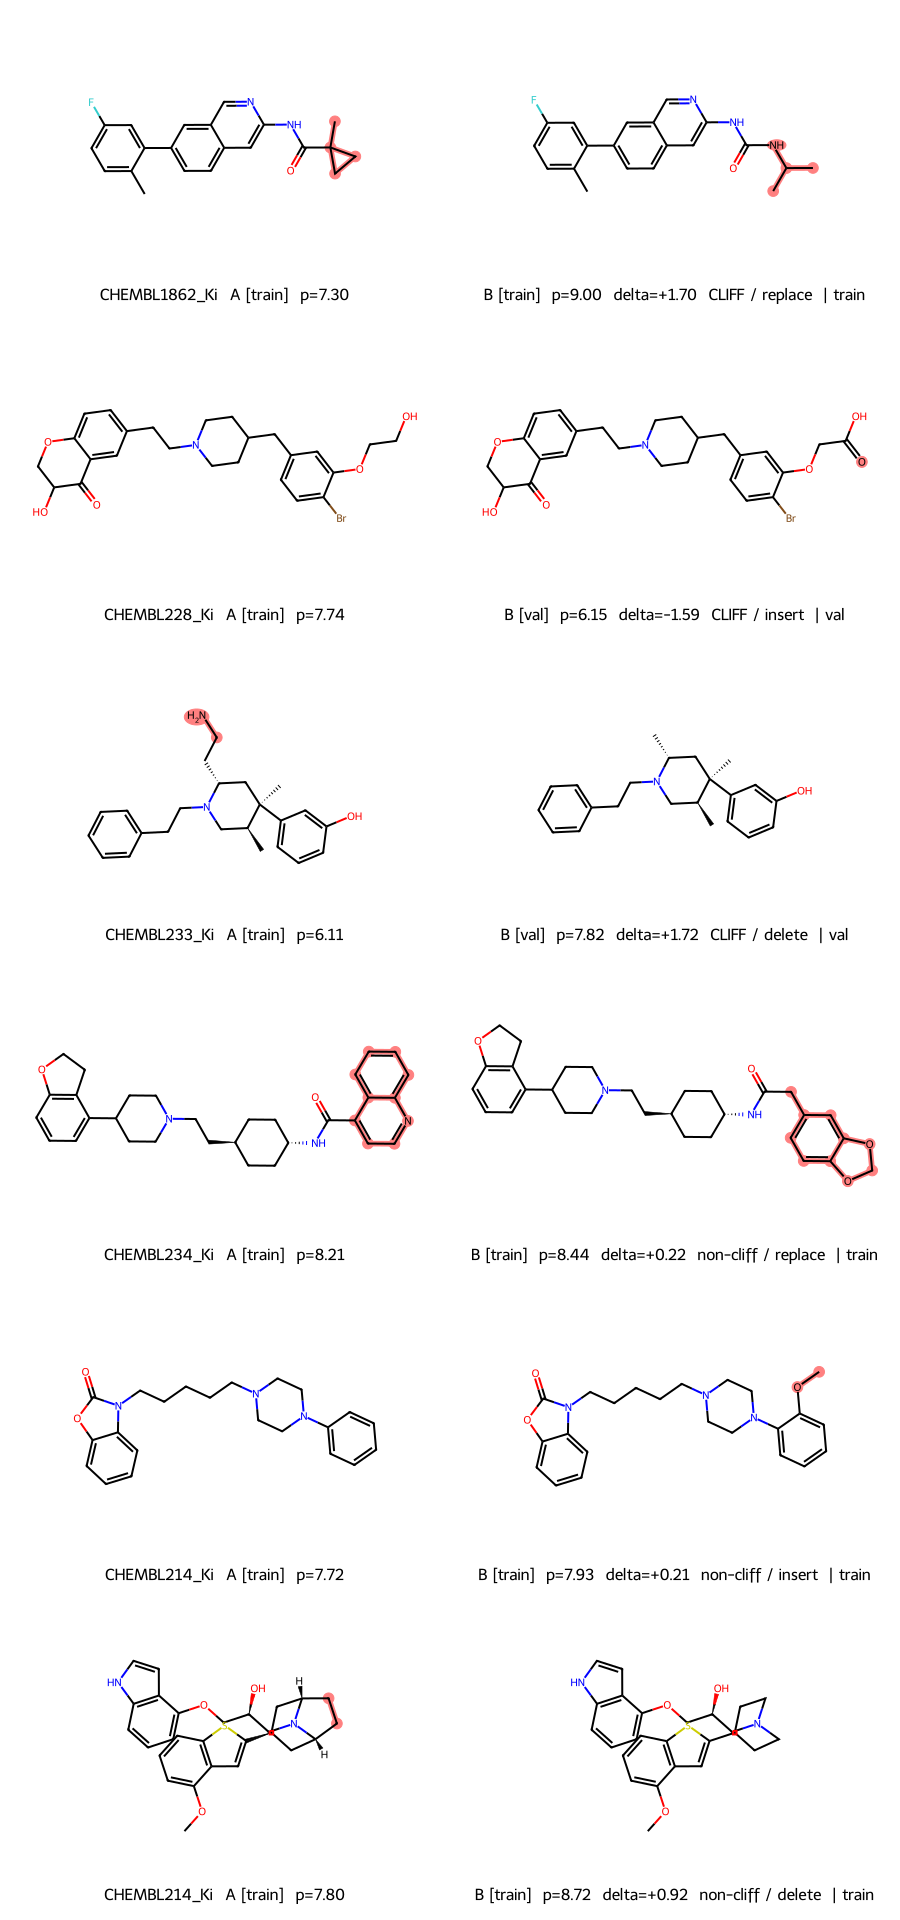

In [11]:
from rdkit.Chem import Draw, rdDepictor

def draw_pairs(rows):
    mols, highlights, legends = [], [], []
    for r in rows.itertuples():
        a, b = Chem.MolFromSmiles(r.smiles_a), Chem.MolFromSmiles(r.smiles_b)
        rdDepictor.Compute2DCoords(a)
        mcs = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                             bondCompare=rdFMCS.BondCompare.CompareOrder, ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
        rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=Chem.MolFromSmarts(mcs.smartsString), acceptFailure=True)
        mols += [a, b]
        highlights += [r.atoms_a, r.atoms_b]
        legends += [f'{r.target}  A [{r.split_a}]  p={r.p_a:.2f}',
                    f'B [{r.split_b}]  p={r.p_b:.2f}  delta={r.delta:+.2f}  {"CLIFF" if r.is_cliff else "non-cliff"} / {r.edit}  | {r.split}']
    return Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(450, 320), highlightAtomLists=highlights, legends=legends)

sample = pairs.groupby(['is_cliff', 'edit']).sample(1, random_state=SEED).sort_values(['is_cliff', 'edit'], ascending=False)
draw_pairs(sample)

## 6. 평가 쌍 예시

평가 분자 하나가 **여러 학습 분자와** 짝을 이룬다.
10번에서 이 학습 분자들의 실측값을 기준으로 평가 분자의 활성을 추정한다.

평가 분자 = CHEMBL237_Ki:998 | 짝이 되는 학습 분자 4 개 중 3개 표시


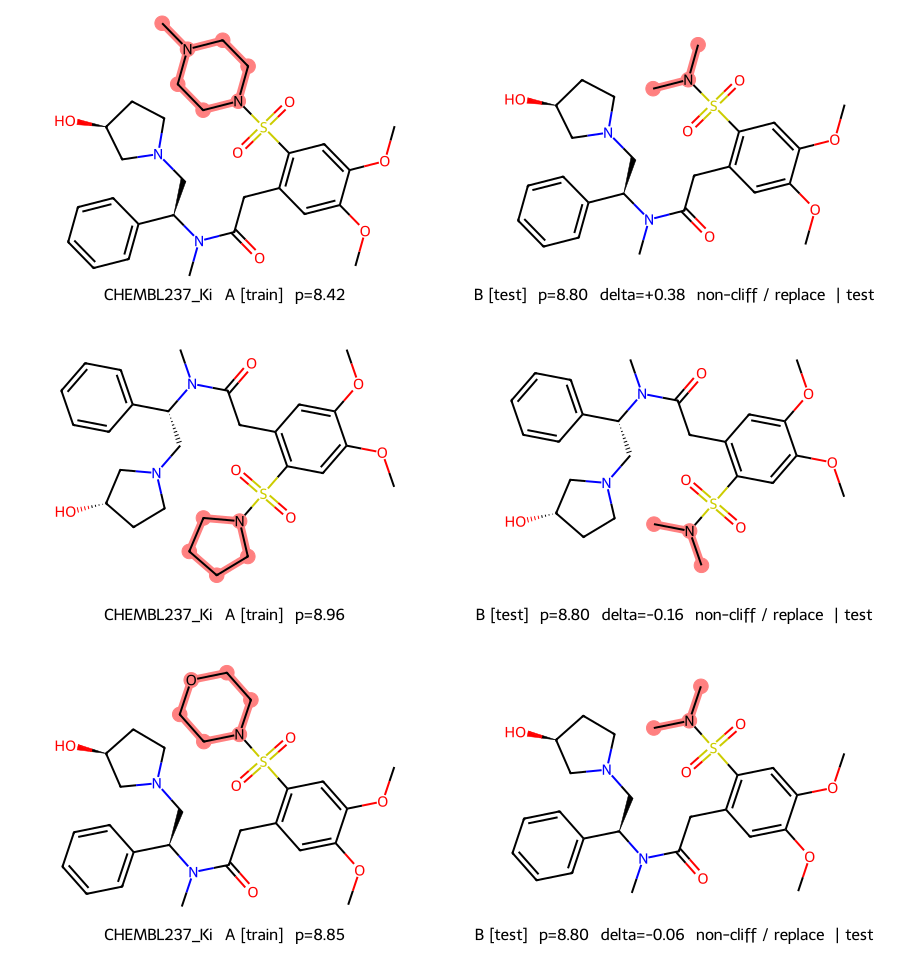

In [12]:
# 평가 쌍마다 평가 분자를 기준(center)으로 펼친 뒤, 학습 분자 짝이 3개 이상인 평가 분자 하나 선택
long = pd.concat([pairs[pairs[s] == 'test'].assign(center=lambda x: x.target + ':' + x[m].astype(str))
                  for m, s in [('i', 'split_a'), ('j', 'split_b')]])
n_ref = long.groupby('center').size()
center = n_ref[n_ref >= 3].sample(1, random_state=SEED).index[0]
print('평가 분자 =', center, '| 짝이 되는 학습 분자', int(n_ref[center]), '개 중 3개 표시')
draw_pairs(long[long.center == center].sample(3, random_state=SEED))

In [13]:
# 모든 쌍에 학습 분자가 하나 이상 있어야 한다 (기준 분자 없는 쌍이 빠졌는지 확인)
assert ((pairs.split_a == 'train') | (pairs.split_b == 'train')).all()
assert set(pairs.split) == set(SPLITS) and not pairs.split.isna().any()
print('쌍 구성 확인 완료: 모든 쌍에 학습 분자 포함')

쌍 구성 확인 완료: 모든 쌍에 학습 분자 포함


## 7. 비교 대상 (SVR)

기존 방식: 분자 하나씩 약효를 예측한 뒤 **두 값을 빼서** 차이를 구한다.
**항상 0이라고 답하는 기준**도 함께 둔다.

In [14]:
from sklearn.svm import SVR

SVR_C = [1, 10, 100, 1000]

def ecfp(smiles):
    return np.array([FPGEN.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) for s in smiles], dtype=np.float32)

def tanimoto(X, Y):
    inter = X @ Y.T
    return inter / (X.sum(1)[:, None] + Y.sum(1)[None, :] - inter)

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def svr_predict(target):
    """train 분자로 학습, val로 C 선택 → 모든 분자의 예측값"""
    df = load(target)
    X = ecfp(df.smiles)
    tr, va = (df.split == 'train').values, (df.split == 'val').values
    K = tanimoto(X, X[tr])
    fit = lambda C: SVR(kernel='precomputed', C=C).fit(K[tr], df.p[tr])
    val_rmse = {C: rmse(fit(C).predict(K[va]), df.p[va]) for C in SVR_C}
    best = min(val_rmse, key=val_rmse.get)
    return df.assign(pred=fit(best).predict(K)), best

mol_pred, rows = {}, []
for t in DEV_TARGETS:
    d, C = svr_predict(t)
    mol_pred[t] = d.pred
    te = d[d.split == 'test']
    rows.append(dict(target=t, C=C, test_rmse=rmse(te.pred, te.p), test_rmse_cliff_mol=rmse(te.pred[te.cliff_mol == 1], te.p[te.cliff_mol == 1])))
for _p in PAIRSETS.values():   # 두 설정의 쌍 모두에 붙인다
    _p['pred_svr'] = [mol_pred[t][j] - mol_pred[t][i] for t, i, j in zip(_p.target, _p.i, _p.j)]
    _p['pred_zero'] = 0.0
svr_mol = pd.DataFrame(rows)
print(f'타깃 {len(svr_mol)}개 학습 완료  |  분자 단위 test RMSE 중앙값 {svr_mol.test_rmse.median():.3f}')

타깃 30개 학습 완료  |  분자 단위 test RMSE 중앙값 0.694


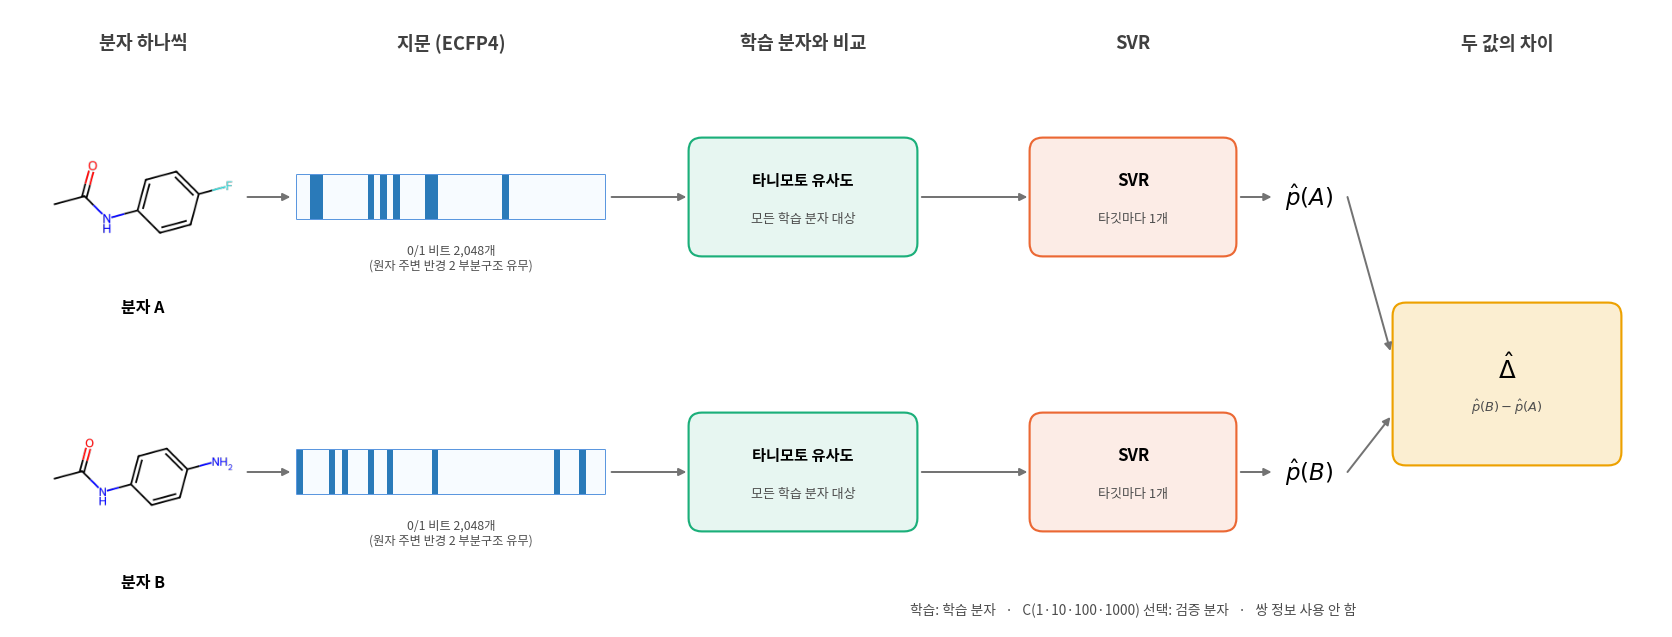

In [15]:
# 비교 대상 SVR이 Δ를 내는 과정. 분자는 RDKit, 글자는 matplotlib
import io
from matplotlib.patches import FancyBboxPatch
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def _mol_img(smiles, size=230):
    mol = Chem.MolFromSmiles(smiles); rdDepictor.Compute2DCoords(mol)
    d = rdMolDraw2D.MolDraw2DCairo(size, size)
    d.drawOptions().clearBackground = False
    d.DrawMolecule(mol); d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig = plt.figure(figsize=(15, 5.6))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 150); ax.set_ylim(0, 56); ax.axis('off')

def box(x, y, w, h, title, sub='', color=C1, fill=0.10, fs=11):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.4,rounding_size=1.2',
                                fc=(*plt.matplotlib.colors.to_rgb(color), fill), ec=color, lw=1.4))
    ax.text(x + w / 2, y + h / 2 + (1.5 if sub else 0), title, ha='center', va='center', fontsize=fs, weight='bold')
    if sub:
        ax.text(x + w / 2, y + h / 2 - 2.0, sub, ha='center', va='center', fontsize=8.5, color='0.3')

def arrow(x0, y0, x1, y1, color='0.45'):
    ax.annotate('', (x1, y1), (x0, y0), arrowprops=dict(arrowstyle='-|>', color=color, lw=1.3, shrinkA=0, shrinkB=0))

for x, t in [(12, '분자 하나씩'), (40, '지문 (ECFP4)'), (72, '학습 분자와 비교'), (102, 'SVR'), (136, '두 값의 차이')]:
    ax.text(x, 52.5, t, ha='center', fontsize=12, weight='bold', color='0.25')

rng = np.random.default_rng(0)
for y, smi, name in [(30, 'CC(=O)Nc1ccc(F)cc1', 'A'), (5, 'CC(=O)Nc1ccc(N)cc1', 'B')]:
    ax.imshow(_mol_img(smi), extent=(3, 21, y, y + 18), zorder=2)
    ax.text(12, y - 0.3, f'분자 {name}', ha='center', va='top', fontsize=10.5, weight='bold')
    # 지문: 2048칸 중 일부만 1인 막대
    bits = (rng.random(48) < 0.18).astype(float)
    ax.imshow(bits[None, :], extent=(26, 54, y + 7, y + 11), cmap='Blues', vmin=0, vmax=1.4, aspect='auto', zorder=2)
    ax.add_patch(plt.Rectangle((26, y + 7), 28, 4, fill=False, ec=C1, lw=1))
    ax.text(40, y + 4.8, '0/1 비트 2,048개\n(원자 주변 반경 2 부분구조 유무)', ha='center', va='top', fontsize=8, color='0.3')
    arrow(21.5, y + 9, 25.4, y + 9)
    box(62, y + 4, 20, 10, '타니모토 유사도', '모든 학습 분자 대상', color=C3, fill=0.10, fs=10)
    arrow(54.6, y + 9, 61.4, y + 9)
    box(93, y + 4, 18, 10, 'SVR', '타깃마다 1개', color=C2, fill=0.12)
    arrow(82.8, y + 9, 92.4, y + 9)
    ax.text(118, y + 9, rf'$\hat{{p}}({name})$', ha='center', va='center', fontsize=15)
    arrow(111.8, y + 9, 114.6, y + 9)

box(126, 15, 20, 14, r'$\hat{\Delta}$', r'$\hat{p}(B) - \hat{p}(A)$', color=C4, fill=0.18, fs=16)
arrow(121.5, 39, 125.4, 25); arrow(121.5, 14, 125.4, 19)
ax.text(102, 1.2, '학습: 학습 분자   ·   C(1·10·100·1000) 선택: 검증 분자   ·   쌍 정보 사용 안 함',
        ha='center', fontsize=9, color='0.3')
plt.show()

### 평가 방법

평가 쌍(평가 분자 – 학습 분자)을 cliff 여부로 나눠 오차(RMSE)를 본다. 낮을수록 좋다.

In [16]:
def rmse_table(df, col, index='split'):
    se = df.assign(se=(df[col] - df.delta) ** 2)
    t = se.pivot_table(index=index, columns='is_cliff', values='se', aggfunc='mean').rename(columns={False: 'non-cliff', True: 'cliff'})
    t['all'] = se.groupby(index).se.mean()
    return t[['cliff', 'non-cliff', 'all']] ** 0.5

pd.concat({m: rmse_table(pairs, f'pred_{m}').loc[SPLITS] for m in ['zero', 'svr']}, axis=1).round(3)

zero                     svr                 
is_cliff  cliff non-cliff    all  cliff non-cliff    all
split                                                   
train     1.744     0.462  0.916  0.423     0.167  0.248
val       1.752     0.464  0.917  0.946     0.446  0.593
test      1.720     0.465  0.910  0.928     0.447  0.590

## 8. 분자를 그래프로 바꾸기

원자는 점, 결합은 선으로 바꿔 모델에 넣는다. 나중에 3D 입력으로 바꿀 자리다.

In [17]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool
from rdkit.Chem.rdchem import HybridizationType as H, BondType as B

ELEMENTS = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'B', 'Si', 'Se']
HYBRID = [H.SP, H.SP2, H.SP3, H.SP3D, H.SP3D2]
BONDS = [B.SINGLE, B.DOUBLE, B.TRIPLE, B.AROMATIC]
EDITS = ['replace', 'insert', 'delete', 'multi']  # multi = 단일 부위가 아닌 학습 전용 쌍 (조각 없음)
FLIP = {'replace': 'replace', 'insert': 'delete', 'delete': 'insert', 'multi': 'multi'}

def onehot(x, choices):
    return [float(x == c) for c in choices] + [float(x not in choices)]

def atom_features(a):
    return (onehot(a.GetSymbol(), ELEMENTS) + onehot(a.GetDegree(), [0, 1, 2, 3, 4, 5]) + onehot(a.GetFormalCharge(), [-1, 0, 1])
            + onehot(a.GetTotalNumHs(), [0, 1, 2, 3]) + onehot(a.GetHybridization(), HYBRID) + [float(a.GetIsAromatic()), float(a.IsInRing())])

def graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    src, dst, edge = [], [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        f = onehot(b.GetBondType(), BONDS) + [float(b.GetIsConjugated())]
        src += [i, j]; dst += [j, i]; edge += [f, f]
    return Data(x=torch.tensor([atom_features(a) for a in mol.GetAtoms()]),
                edge_index=torch.tensor([src, dst], dtype=torch.long).reshape(2, -1),
                edge_attr=torch.tensor(edge).reshape(-1, len(BONDS) + 2))

graphs = {(t, k): graph(s) for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
N_ATOM, N_BOND = len(atom_features(Chem.MolFromSmiles('C').GetAtomWithIdx(0))), len(BONDS) + 2

def with_mask(g, atoms):
    mask = torch.zeros(g.num_nodes, dtype=torch.bool)
    mask[torch.tensor(atoms, dtype=torch.long)] = True  # atoms가 비면(multi 쌍) 전부 False → f = 0 벡터
    return Data(x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr, mask=mask)

def samples(df, both_directions=False, reverse=False):
    """reverse=True면 (B, A, −Δ)만 만든다. 양방향 평균 예측에 쓴다"""
    out = []
    for r in df.itertuples():
        ga, gb = with_mask(graphs[r.target, r.i], r.atoms_a), with_mask(graphs[r.target, r.j], r.atoms_b)
        t = DEV_TARGETS.index(r.target)
        fwd = (ga, gb, EDITS.index(r.edit), t, r.delta)
        rev = (gb, ga, EDITS.index(FLIP[r.edit]), t, -r.delta)
        out += [fwd, rev] if both_directions else [rev] if reverse else [fwd]
    return out

def collate(batch):
    ga, gb, edit, tgt, y = zip(*batch)
    return (Batch.from_data_list(ga), Batch.from_data_list(gb),
            torch.tensor(edit), torch.tensor(tgt), torch.tensor(y, dtype=torch.float32))

ga, gb, edit, tgt, y = collate(samples(pairs.head(2)))
print('원자 특징', N_ATOM, '| 결합 특징', N_BOND, '| 타깃', len(DEV_TARGETS),
      '| 배치 A 노드', ga.num_nodes, '| mask 원자', int(ga.mask.sum()), '| edit', edit.tolist())

/home/bising0922/micromamba/envs/aienv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


원자 특징 37 | 결합 특징 6 | 타깃 30 | 배치 A 노드 54 | mask 원자 12 | edit [0, 2]


## 9. 모델 학습

### 구조

두 분자와 **바뀐 부분을 따로** 읽어서 약효 차이를 바로 예측한다.

| 부분 | 하는 일 |
|---|---|
| 분자 인코더 | 분자 전체를 읽어 원자 벡터를 만들고 **평균** → `h(A)`, `h(B)` |
| 조각 인코더 | **바뀐 원자만** 골라 평균 → `f(A)`, `f(B)`. 없으면 0 |
| 예측 헤드 | `h(A), h(B), h(B)−h(A), f(A), f(B)` + 편집 종류 + 타깃 → MLP → Δ̂ |

두 인코더는 구조가 같지만 **가중치는 서로 다르다**. A와 B는 같은 인코더를 쓴다.
분자 인코더 자리가 나중에 **3D CNN으로 바뀔 자리**다.

### 인코더: GINE 3층

```python
GINEConv(nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 64)), edge_dim=6)
```

한 층은 **자기 자신 + 이웃들을 합친 뒤 MLP에 통과**시킨다.

```
h'(v) = MLP( (1+ε)·h(v) + Σ ReLU( h(u) + e(u,v) ) )
                          이웃 u
```

- **평균이 아니라 합**이라서 이웃의 개수까지 구분된다 (GIN의 핵심)
- `e(u,v)`가 **결합 특징**이다. 이게 없으면 단일결합과 이중결합을 구분 못 한다 (GINE가 GIN에 더한 부분)

| | |
|---|---|
| MLP | 64 → 64 → 64 (중간에 ReLU) |
| 엣지 특징 | 6차원 (결합 종류 4 + 기타 + 공액 여부) → 내부에서 64로 투영 |
| ε | 0 고정 (학습 안 함) |
| 층 수 | 3층 → 각 원자가 **3결합 떨어진 곳까지** 봄 |

여기에 **잔차 연결**(`h = h + ReLU(conv(h))`)을 덧붙였다. GINE 자체에는 없는 부분으로,
층을 쌓아도 원래 원자 정보가 씻겨나가지 않게 한다.

### 손실

약효 차이가 큰 쌍에 **가중치(α)** 를 더 줘서 cliff를 더 신경 쓰게 한다. α = 0이면 가중치 없음.

In [18]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# 공용 GPU다. 쌍 생성·그래프 변환에 수 분이 걸리는 사이 다른 사용자가 GPU를 통째로 채우면
# 학습 시작 시점에 OOM이 난다. 실제로 겪었으므로 미리 4GB를 잡아 캐싱 할당자에 남긴다
if torch.cuda.is_available():
    _reserve = torch.empty(int(4e9 // 4), dtype=torch.float32, device='cuda'); del _reserve
HIDDEN, LAYERS, BATCH, LR, EPOCHS = 64, 3, 256, 1e-3, 200
DROPOUT, WD = 0.3, 1e-4   # 과적합 대응: 폭 128→64, dropout 0.1→0.3, weight decay
# 30개 타깃이면 epoch당 본 쌍이 12.7배라 훨씬 적은 epoch에 수렴한다 → patience를 줄인다
PATIENCE = 8 if USE_ALL_TARGETS else 20
ALPHAS = [0, 0.5, 1, 2, 4]  # α를 하나로 고르지 않고 cliff↔non-cliff 교환 곡선을 그린다.
                            # {0, 2} × 시드 3개는 이미 캐시돼 있어 9회만 새로 학습한다
RUNS = 'runs'
os.makedirs(RUNS, exist_ok=True)

def log(*msg):
    print(*msg)
    with open(f'{RUNS}/train.log', 'a') as f:
        print(pd.Timestamp.now().strftime('%m-%d %H:%M:%S'), *msg, file=f)


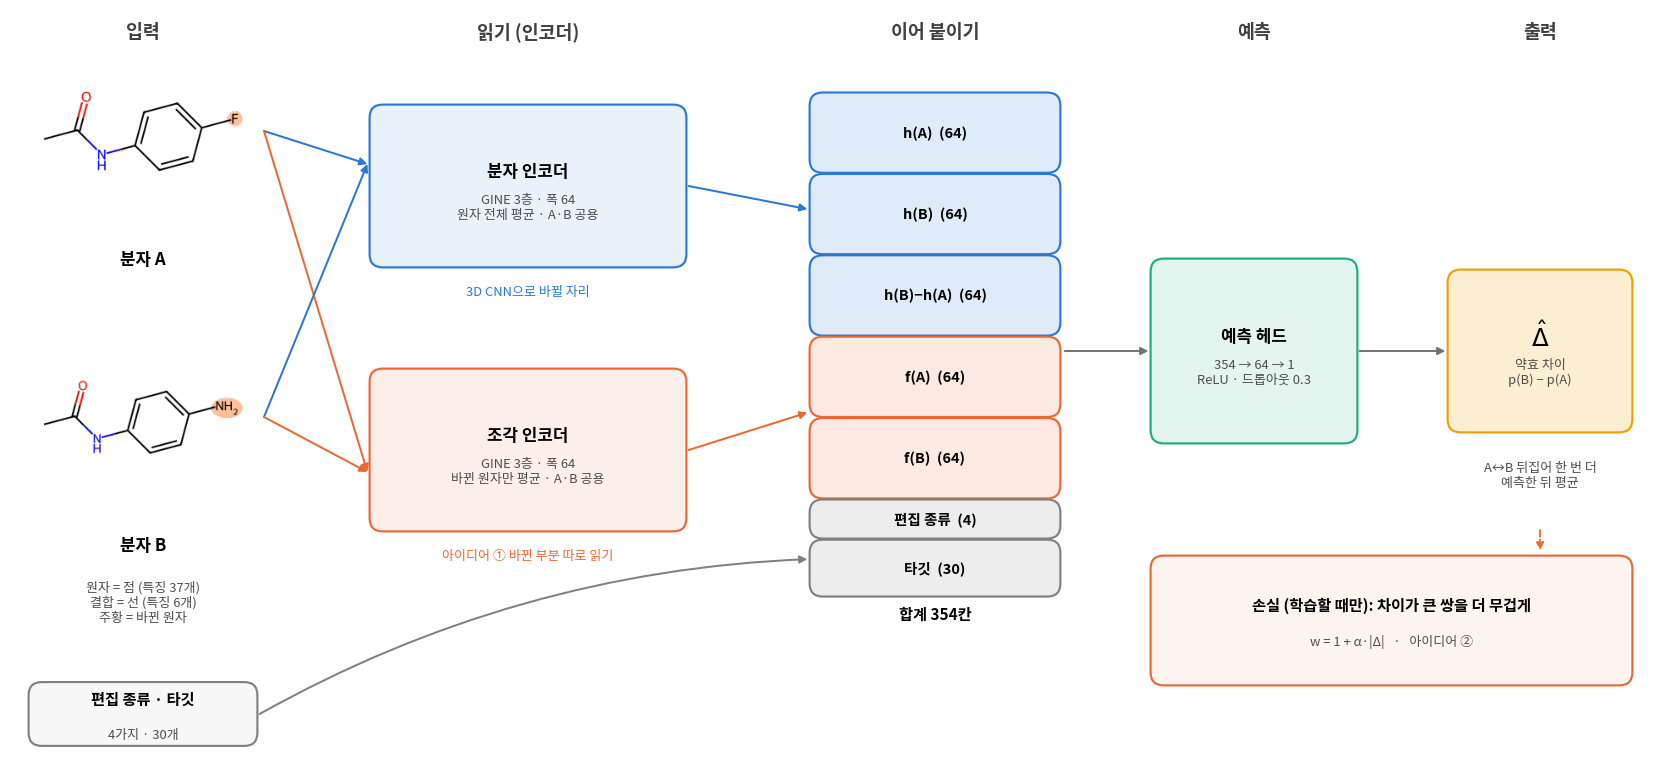

In [19]:
# 모델 구조 한 장 요약 (입력 → 출력). 분자는 RDKit, 글자는 matplotlib (RDKit 폰트엔 한글이 없다)
import io
from matplotlib.patches import FancyBboxPatch
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def mol_png(smiles, atoms, size=260):
    mol = Chem.MolFromSmiles(smiles); rdDepictor.Compute2DCoords(mol)
    d = rdMolDraw2D.MolDraw2DCairo(size, size)
    d.drawOptions().clearBackground = False
    d.DrawMolecule(mol, highlightAtoms=atoms, highlightAtomColors={i: (1, .75, .6) for i in atoms}, highlightBonds=[])
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig = plt.figure(figsize=(15, 7))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 150); ax.set_ylim(0, 69); ax.axis('off')

def box(x, y, w, h, title, sub='', color=C1, fill=0.10, fs=11):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.4,rounding_size=1.2',
                                fc=(*plt.matplotlib.colors.to_rgb(color), fill), ec=color, lw=1.4))
    ax.text(x + w / 2, y + h / 2 + (1.4 if sub else 0), title, ha='center', va='center', fontsize=fs, weight='bold')
    if sub:
        ax.text(x + w / 2, y + h / 2 - 1.9, sub, ha='center', va='center', fontsize=8.5, color='0.3')

def arrow(x0, y0, x1, y1, color='0.45', **kw):
    ax.annotate('', (x1, y1), (x0, y0), arrowprops=dict(arrowstyle='-|>', color=color, lw=1.3, shrinkA=0, shrinkB=0, **kw))

def stage(x, text):
    ax.text(x, 66.5, text, ha='center', fontsize=12, weight='bold', color='0.25')

stage(12, '입력'); stage(47, '읽기 (인코더)'); stage(84, '이어 붙이기'); stage(113, '예측'); stage(139, '출력')

# ── 입력: 실제 분자쌍 (바뀐 원자 주황)
for y, smi, hl, name in [(48, 'CC(=O)Nc1ccc(F)cc1', [8], '분자 A'), (22, 'CC(=O)Nc1ccc(N)cc1', [8], '분자 B')]:
    ax.imshow(mol_png(smi, hl), extent=(2, 22, y, y + 20), zorder=2)
    ax.text(12, y - 0.8, name, ha='center', va='top', fontsize=11, weight='bold')
ax.text(12, 17.2, f'원자 = 점 (특징 {N_ATOM}개)\n결합 = 선 (특징 {N_BOND}개)\n주황 = 바뀐 원자', ha='center', va='top', fontsize=8.5, color='0.3')
box(2, 2.5, 20, 5, '편집 종류 · 타깃', f'{len(EDITS)}가지 · {len(DEV_TARGETS)}개', color='0.5', fill=0.06, fs=10)

# ── 인코더 두 개 (A, B가 같은 인코더를 함께 쓴다)
box(33, 46, 28, 14, '분자 인코더', f'GINE {LAYERS}층 · 폭 {HIDDEN}\n원자 전체 평균 · A·B 공용', color=C1)
box(33, 22, 28, 14, '조각 인코더', f'GINE {LAYERS}층 · 폭 {HIDDEN}\n바뀐 원자만 평균 · A·B 공용', color=C2)
ax.text(47, 44, '3D CNN으로 바뀔 자리', ha='center', va='top', fontsize=8.5, color=C1, style='italic')
ax.text(47, 20, '아이디어 ① 바뀐 부분 따로 읽기', ha='center', va='top', fontsize=8.5, color=C2, style='italic')
for y0 in (58, 32):          # A, B 둘 다 두 인코더로
    arrow(23, y0, 32.4, 55, color=C1); arrow(23, y0, 32.4, 27, color=C2)

# ── 이어 붙이기: 7조각 = 354
parts = [('h(A)', HIDDEN, C1), ('h(B)', HIDDEN, C1), ('h(B)−h(A)', HIDDEN, C1),
         ('f(A)', HIDDEN, C2), ('f(B)', HIDDEN, C2), ('편집 종류', len(EDITS), '0.5'), ('타깃', len(DEV_TARGETS), '0.5')]
n_in = sum(n for _, n, _ in parts)
y, mid = 62, {}
for name, n, c in parts:
    h = 3.4 + 4.0 * n / HIDDEN
    box(73, y - h, 22, h - 0.9, f'{name}  ({n})', color=c, fill=0.14, fs=9.5)
    mid.setdefault(c, []).append(y - h / 2)
    y -= h
ax.text(84, y - 1.2, f'합계 {n_in}칸', ha='center', va='top', fontsize=10, weight='bold')
arrow(61.6, 53, 72.4, np.mean(mid[C1]), color=C1); arrow(61.6, 29, 72.4, np.mean(mid[C2]), color=C2)
arrow(22.6, 5, 72.4, y + 3, color='0.5', connectionstyle='arc3,rad=-0.12')

# ── 예측 헤드
box(104, 30, 18, 16, '예측 헤드', f'{n_in} → {HIDDEN} → 1\nReLU · 드롭아웃 {DROPOUT}', color=C3, fill=0.12)
arrow(95.8, 38, 103.4, 38)

# ── 출력
box(131, 31, 16, 14, r'$\hat{\Delta}$', '약효 차이\np(B) − p(A)', color=C4, fill=0.18, fs=16)
arrow(122.6, 38, 130.4, 38)
ax.text(139, 28, 'A↔B 뒤집어 한 번 더\n예측한 뒤 평균', ha='center', va='top', fontsize=8.5, color='0.3')

# ── 학습 신호
box(104, 8, 43, 11, '손실 (학습할 때만): 차이가 큰 쌍을 더 무겁게',
    'w = 1 + α·|Δ|   ·   아이디어 ②', color=C2, fill=0.07, fs=10)
ax.annotate('', (139, 19.6), (139, 22.0), arrowprops=dict(arrowstyle='-|>', color=C2, lw=1.2, ls='--'))
plt.show()

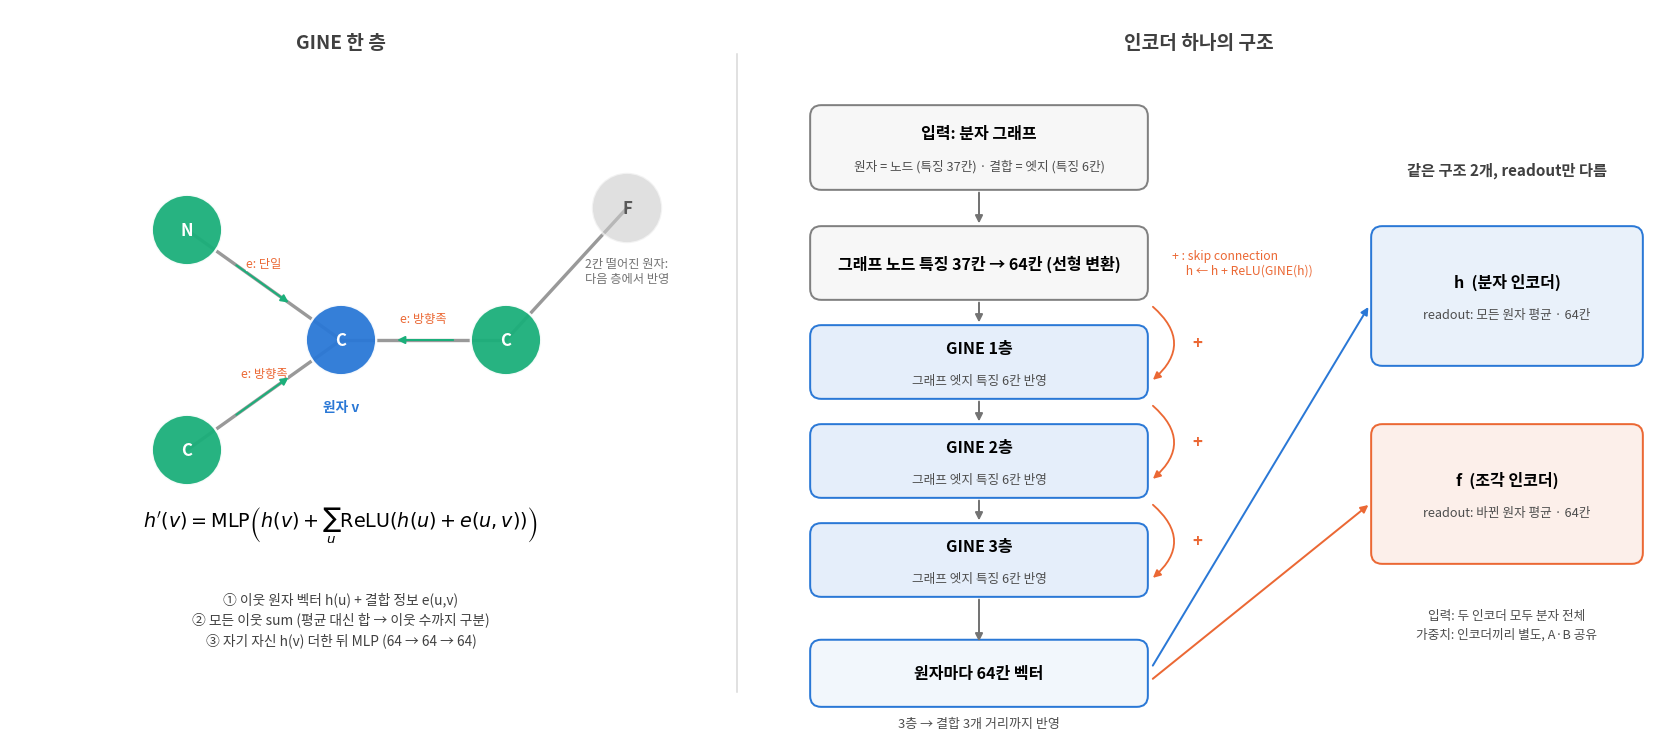

In [20]:
# GINE 인코더 한 층이 하는 일(왼쪽)과 층을 쌓는 방식(오른쪽)
from matplotlib.patches import FancyBboxPatch, Circle

fig = plt.figure(figsize=(15, 6.6))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 150); ax.set_ylim(0, 66); ax.axis('off')

def box(x, y, w, h, title, sub='', color=C1, fill=0.10, fs=10.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.35,rounding_size=1.0',
                                fc=(*plt.matplotlib.colors.to_rgb(color), fill), ec=color, lw=1.3))
    ax.text(x + w / 2, y + h / 2 + (1.3 if sub else 0), title, ha='center', va='center', fontsize=fs, weight='bold')
    if sub:
        ax.text(x + w / 2, y + h / 2 - 1.7, sub, ha='center', va='center', fontsize=8.3, color='0.3')

def arrow(x0, y0, x1, y1, color='0.45', **kw):
    ax.annotate('', (x1, y1), (x0, y0), arrowprops=dict(arrowstyle='-|>', color=color, lw=1.3, shrinkA=0, shrinkB=0, **kw))

# ── 왼쪽: 한 층에서 원자 v가 이웃 정보를 모으는 모습
ax.text(30, 62.5, 'GINE 한 층', ha='center', fontsize=12.5, weight='bold', color='0.25')
pos = {'v': (30, 36), 'u1': (16, 46), 'u2': (16, 26), 'u3': (45, 36), 'w': (56, 48)}
lab = {'v': 'C', 'u1': 'N', 'u2': 'C', 'u3': 'C', 'w': 'F'}
for a, b, kind in [('v', 'u1', '단일'), ('v', 'u2', '방향족'), ('v', 'u3', '방향족'), ('u3', 'w', '단일')]:
    (x0, y0), (x1, y1) = pos[a], pos[b]
    ax.plot([x0, x1], [y0, y1], color='0.6', lw=2.2, zorder=1)
    if b != 'w':
        ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 1.6, f'e: {kind}', fontsize=8, color=C2, ha='center',
                bbox=dict(fc='white', ec='none', pad=0.3))
for k, (x, y) in pos.items():
    c = C1 if k == 'v' else ('0.8' if k == 'w' else C3)
    ax.add_patch(Circle((x, y), 3.2, fc=c, ec='white', lw=1.5, zorder=3, alpha=0.95 if k != 'w' else 0.6))
    ax.text(x, y, lab[k], ha='center', va='center', fontsize=11, weight='bold', color='white' if k != 'w' else '0.35', zorder=4)
for k in ('u1', 'u2', 'u3'):
    (x0, y0), (x1, y1) = pos[k], pos['v']
    arrow(x0 + (x1 - x0) * 0.32, y0 + (y1 - y0) * 0.32, x0 + (x1 - x0) * 0.66, y0 + (y1 - y0) * 0.66, color=C3)
ax.text(30, 30.5, '원자 v', ha='center', va='top', fontsize=9, color=C1, weight='bold')
ax.text(56, 43.5, '2칸 떨어진 원자:\n다음 층에서 반영', ha='center', va='top', fontsize=8, color='0.45')
ax.text(30, 19, r"$h'(v) = \mathrm{MLP}\left( h(v) + \sum_{u} \mathrm{ReLU}\left( h(u) + e(u,v) \right) \right)$",
        ha='center', fontsize=12.5)
ax.text(30, 13.2, '① 이웃 원자 벡터 h(u) + 결합 정보 e(u,v)\n'
                  '② 모든 이웃 sum (평균 대신 합 → 이웃 수까지 구분)\n'
                  '③ 자기 자신 h(v) 더한 뒤 MLP (64 → 64 → 64)', ha='center', va='top', fontsize=9, color='0.25',
        linespacing=1.5)

ax.plot([66, 66], [4, 62], color='0.85', lw=1)

# ── 오른쪽: 층 쌓기
ax.text(108, 62.5, '인코더 하나의 구조', ha='center', fontsize=12.5, weight='bold', color='0.25')
x0, w = 73, 30
box(x0, 50, w, 7, f'입력: 분자 그래프', f'원자 = 노드 (특징 {N_ATOM}칸) · 결합 = 엣지 (특징 {N_BOND}칸)', color='0.5', fill=0.06)
arrow(x0 + w / 2, 49.4, x0 + w / 2, 46.6)
box(x0, 40, w, 6, f'그래프 노드 특징 {N_ATOM}칸 → {HIDDEN}칸 (선형 변환)', color='0.5', fill=0.06)
ys = [31, 22, 13]
prev = 39.4
for k, y in enumerate(ys, 1):
    arrow(x0 + w / 2, prev, x0 + w / 2, y + 6.6)
    box(x0, y, w, 6, f'GINE {k}층', f'그래프 엣지 특징 {N_BOND}칸 반영', color=C1, fill=0.12)
    # 잔차 연결: 입력을 그대로 옆으로 돌려 더한다
    ax.annotate('', (x0 + w + 0.6, y + 1.2), (x0 + w + 0.6, y + 8.2),
                arrowprops=dict(arrowstyle='-|>', color=C2, lw=1.2, connectionstyle='arc3,rad=-0.6'))
    ax.text(x0 + w + 4.4, y + 4.7, '+', fontsize=11, color=C2, weight='bold', va='center')
    prev = y - 0.6
ax.text(x0 + w + 2.5, 43, '+ : skip connection\n     h ← h + ReLU(GINE(h))', fontsize=8, color=C2, va='center')
arrow(x0 + w / 2, prev, x0 + w / 2, 8.6)
box(x0, 3, w, 5.4, f'원자마다 {HIDDEN}칸 벡터', color=C1, fill=0.06)
ax.text(x0 + w / 2, 0.8, f'{LAYERS}층 → 결합 {LAYERS}개 거리까지 반영', ha='center', fontsize=8.5, color='0.3')

# 두 인코더가 이 구조를 각각 갖는다
box(124, 34, 24, 12, 'h  (분자 인코더)', 'readout: 모든 원자 평균 · 64칸', color=C1, fill=0.10)
box(124, 16, 24, 12, 'f  (조각 인코더)', 'readout: 바뀐 원자 평균 · 64칸', color=C2, fill=0.10)
ax.text(136, 51, '같은 구조 2개, readout만 다름', ha='center', fontsize=10, weight='bold', color='0.25')
ax.text(136, 11.5, '입력: 두 인코더 모두 분자 전체\n가중치: 인코더끼리 별도, A·B 공유',
        ha='center', va='top', fontsize=8.3, color='0.3', linespacing=1.45)
arrow(103.8, 6.4, 123.4, 39, color=C1)
arrow(103.8, 5.2, 123.4, 21, color=C2)
plt.show()

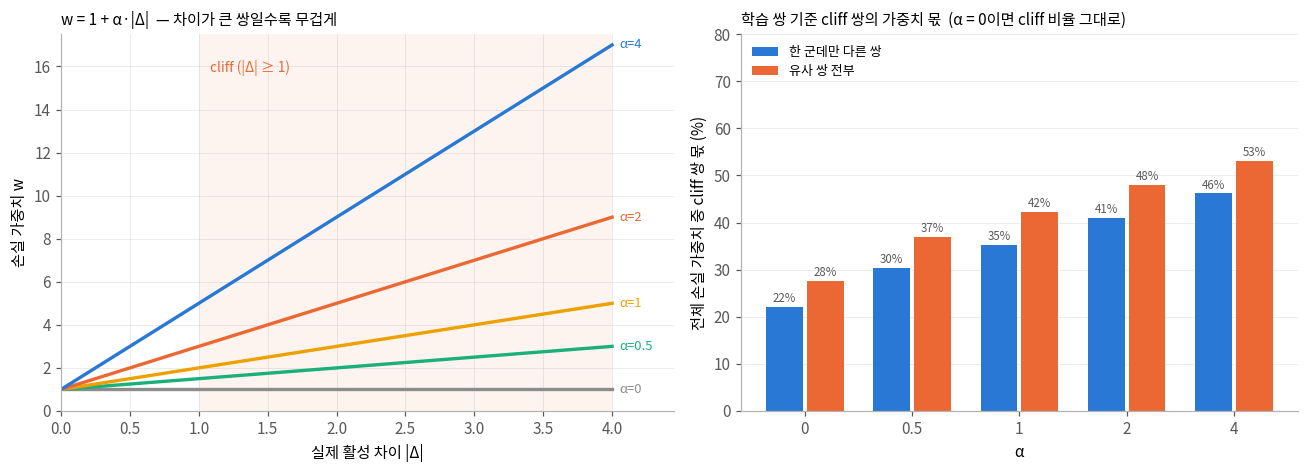

In [21]:
# 손실 가중치 w = 1 + α·|Δ| (왼쪽)와, 실제 학습 쌍에서 cliff 쌍이 차지하는 가중치 몫 (오른쪽)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw=dict(width_ratios=[1.1, 1]))
d = np.linspace(0, 4, 200)
cols = dict(zip(ALPHAS, ['0.55', C3, C4, C2, C1]))
a1.axvspan(CLIFF, 4, color=C2, alpha=0.07, lw=0)
a1.text(CLIFF + 0.08, 16.3, f'cliff (|Δ| ≥ {CLIFF:g})', fontsize=9, color=C2, va='top')
for a in ALPHAS:
    a1.plot(d, 1 + a * d, color=cols[a], lw=2.2, label=f'α = {a:g}')
    a1.text(4.05, 1 + a * 4, f'α={a:g}', fontsize=8.5, color=cols[a], va='center')
a1.set(xlim=(0, 4.45), ylim=(0, 17.5), xlabel='실제 활성 차이 |Δ|', ylabel='손실 가중치 w')
a1.set_title('w = 1 + α·|Δ|  — 차이가 큰 쌍일수록 무겁게', loc='left', fontsize=10)
tidy(a1)

names = {'single': '한 군데만 다른 쌍', 'all': '유사 쌍 전부'}
x = np.arange(len(ALPHAS)); bw = 0.38
for k, (st, ps) in enumerate(PAIRSETS.items()):
    tr = ps[ps.split == 'train']
    share = [((1 + a * tr.delta.abs()) * tr.is_cliff).sum() / (1 + a * tr.delta.abs()).sum() for a in ALPHAS]
    bars = a2.bar(x + (k - 0.5) * bw, np.array(share) * 100, bw * 0.9, color=[C1, C2][k], label=names[st], zorder=2)
    for b, v in zip(bars, share):
        a2.text(b.get_x() + b.get_width() / 2, v * 100 + 1, f'{v:.0%}', ha='center', fontsize=7.5, color='0.35')
a2.set(xticks=x, ylim=(0, 80), xlabel='α', ylabel='전체 손실 가중치 중 cliff 쌍 몫 (%)')
a2.set_xticklabels([f'{a:g}' for a in ALPHAS])
a2.set_title('학습 쌍 기준 cliff 쌍의 가중치 몫  (α = 0이면 cliff 비율 그대로)', loc='left', fontsize=10)
a2.legend(fontsize=8.5, frameon=False, loc='upper left'); a2.grid(axis='x', visible=False); tidy(a2)
fig.tight_layout(); plt.show()

In [22]:
class GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp = nn.Linear(N_ATOM, HIDDEN)
        self.convs = nn.ModuleList(GINEConv(nn.Sequential(nn.Linear(HIDDEN, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, HIDDEN)), edge_dim=N_BOND)
                                   for _ in range(LAYERS))

    def forward(self, g):
        h = self.inp(g.x)
        for conv in self.convs:
            h = h + F.relu(conv(h, g.edge_index, g.edge_attr))
        return h  # 원자별 벡터

def masked_mean(h, g):
    m = g.mask.float().unsqueeze(1)
    return global_add_pool(h * m, g.batch, g.num_graphs) / global_add_pool(m, g.batch, g.num_graphs).clamp(min=1)

class PairModel(nn.Module):
    """타깃 one-hot을 입력에 넣는다. 30개 타깃에서는 고유 분자 35,633개 중 9,507개(26.7%)가
    2개 이상 타깃에 등장하므로, 타깃 정보가 없으면 같은 쌍이 서로 다른 Δ를 갖는 것을 구분할 수 없다"""
    def __init__(self):
        super().__init__()
        self.mol, self.frag = GNN(), GNN()
        n_in = 5 * HIDDEN + len(EDITS) + len(DEV_TARGETS)
        self.head = nn.Sequential(nn.Linear(n_in, HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(HIDDEN, 1))

    def forward(self, ga, gb, edit, tgt):
        ha, hb = global_mean_pool(self.mol(ga), ga.batch), global_mean_pool(self.mol(gb), gb.batch)
        fa, fb = masked_mean(self.frag(ga), ga), masked_mean(self.frag(gb), gb)
        x = torch.cat([ha, hb, hb - ha, fa, fb,
                       F.one_hot(edit, len(EDITS)).float(),
                       F.one_hot(tgt, len(DEV_TARGETS)).float()], 1)
        return self.head(x).squeeze(1)

def forward_pred(model, loader):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE)).cpu()
                          for ga, gb, e, t, _ in loader]).numpy()

def loaders(df):
    """(정방향, 역방향) loader 한 쌍"""
    return (DataLoader(samples(df), 1024, collate_fn=collate),
            DataLoader(samples(df, reverse=True), 1024, collate_fn=collate))

def predict(model, lds):
    """양방향 평균 Δ̂ = (Δ̂(A,B) − Δ̂(B,A)) / 2.
    모델은 반대칭 Δ̂(B,A) = −Δ̂(A,B) 를 정확히 지키지 않으므로, 평균이 그 어긋남만큼 오차를 깎는다"""
    return (forward_pred(model, lds[0]) - forward_pred(model, lds[1])) / 2


def build(pset):
    """한 설정의 loader 묶음을 만든다"""
    tr = pset[pset.split == 'train']
    va = pset[pset.split.str.startswith('val')]
    # num_workers=8: 실측 배치당 68.7ms → 55.1ms. 16은 과다구독으로 오히려 느리다
    loader = DataLoader(samples(tr, both_directions=True), BATCH, shuffle=True,
                        collate_fn=collate, num_workers=8, persistent_workers=True, pin_memory=True)
    # 학습 곡선용: 학습 쌍을 검증과 같은 규모로 고정 추출 (두 곡선의 격차를 과적합으로 읽기 위해)
    te = tr.sample(len(va), random_state=SEED)
    return dict(train_loader=loader, val=va, val_lds=loaders(va), all_lds=loaders(pset),
                train_eval=te, train_eval_lds=loaders(te))

def scores(df, lds, model):
    p = predict(model, lds)
    m = df.is_cliff.values
    return rmse(p, df.delta), rmse(p[m], df.delta[m])

def train(alpha, seed, B, tag):
    path = f'{RUNS}/gnn_a{alpha}_{tag}_seed{seed}.pt'
    hist_path = f'{RUNS}/hist_a{alpha}_{tag}_seed{seed}.csv'
    torch.manual_seed(seed)
    model = PairModel().to(DEVICE)
    if os.path.exists(path) and os.path.exists(hist_path):
        model.load_state_dict(torch.load(path))   # 캐시 사용 — 로그에 남기지 않는다
        return model
    hist = []
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    best, best_state, wait = float('inf'), None, 0
    for epoch in range(EPOCHS):
        model.train()
        for ga, gb, e, t, y in B['train_loader']:
            ga, gb, e, t, y = ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE), y.to(DEVICE)
            w = 1 + alpha * y.abs()
            loss = (w * (model(ga, gb, e, t) - y) ** 2).sum() / w.sum()
            opt.zero_grad(); loss.backward(); opt.step()
        score, cliff = scores(B['val'], B['val_lds'], model)
        tr_, tr_cliff = scores(B['train_eval'], B['train_eval_lds'], model)
        hist.append(dict(epoch=epoch, train=tr_, train_cliff=tr_cliff, val=score, val_cliff=cliff))
        if score < best:
            best, wait = score, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if epoch % 5 == 0 or wait >= PATIENCE:
            log(f'{tag[:6]} a={alpha} s={seed} epoch={epoch} val_rmse={score:.3f} val_cliff={cliff:.3f} best={best:.3f}')
        if wait >= PATIENCE:
            break
    model.load_state_dict(best_state)
    # 끝까지 학습한 경우에만 저장 → 중간에 끊겨도 캐시가 오염되지 않는다
    pd.DataFrame(hist).assign(best_epoch=int(np.argmin([h['val'] for h in hist]))).to_csv(hist_path, index=False)
    torch.save(best_state, path)
    return model

import glob

def pred_cache(prefix, tag, files):
    """가중치·학습 기록이 모두 있을 때만 예측값 캐시 경로를 준다.
    이름에 그 파일들의 최신 수정 시각을 넣어, 다시 학습하면 옛 예측값을 쓰지 않는다"""
    if not all(os.path.exists(f) for f in files):
        return None
    return f'{RUNS}/{prefix}_{tag}_{int(max(os.path.getmtime(f) for f in files))}.pkl'

def save_cache(path, df):
    for old in glob.glob(f'{path.rsplit("_", 1)[0]}_*.pkl'):   # 같은 태그의 옛 캐시는 지운다
        os.remove(old)
    df.to_pickle(path)

# 설정마다 학습 쌍과 평가 쌍을 같은 종류로 맞춘다
KEY = ['target', 'i', 'j']
TAGS, RESULTS = {}, {}
for setting, pset in PAIRSETS.items():
    tag = f't{len(DEV_TARGETS)}_h{HIDDEN}_dr{DROPOUT}_wd{WD}_exp{1 if setting == "all" else 0}_anchored'   # 검증 쌍에서 hard 제외
    TAGS[setting] = tag
    cols = [f'pred_gnn_a{a}_s{s}' for a in ALPHAS for s in SEEDS] + [f'pred_gnn_a{a}_fwd' for a in ALPHAS]
    files = [f'{RUNS}/{k}_a{a}_{tag}_seed{s}.{x}' for a in ALPHAS for s in SEEDS for k, x in [('gnn', 'pt'), ('hist', 'csv')]]
    cache = pred_cache('preds', tag, files)
    if cache and os.path.exists(cache):
        # 예측값 캐시: 학습도 예측도 건너뛴다 (그림·표만 고칠 때 수 분)
        cached = pd.read_pickle(cache)
        assert (cached[KEY].values == pset[KEY].values).all(), '쌍 순서가 캐시와 다르다'
        for col in cols:
            pset[col] = cached[col].values
        log(f'[{setting}] 예측값 캐시 사용: {os.path.basename(cache)}')
    else:
        B = build(pset)
        log(f'[{setting}] 학습 쌍 {len(B["train_loader"].dataset):,} | 검증 {len(B["val"]):,} | 평가 전체 {len(pset):,}')
        for a in ALPHAS:
            for s in SEEDS:
                m = train(a, s, B, tag)
                pset[f'pred_gnn_a{a}_s{s}'] = predict(m, B['all_lds'])
                if s == SEEDS[0]:
                    pset[f'pred_gnn_a{a}_fwd'] = forward_pred(m, B['all_lds'][0])
        save_cache(pred_cache('preds', tag, files), pset[KEY + cols])
    RESULTS[setting] = pset

[single] 예측값 캐시 사용: preds_t30_h64_dr0.3_wd0.0001_exp0_anchored_1790960608.pkl


[all] 예측값 캐시 사용: preds_t30_h64_dr0.3_wd0.0001_exp1_anchored_1790996805.pkl


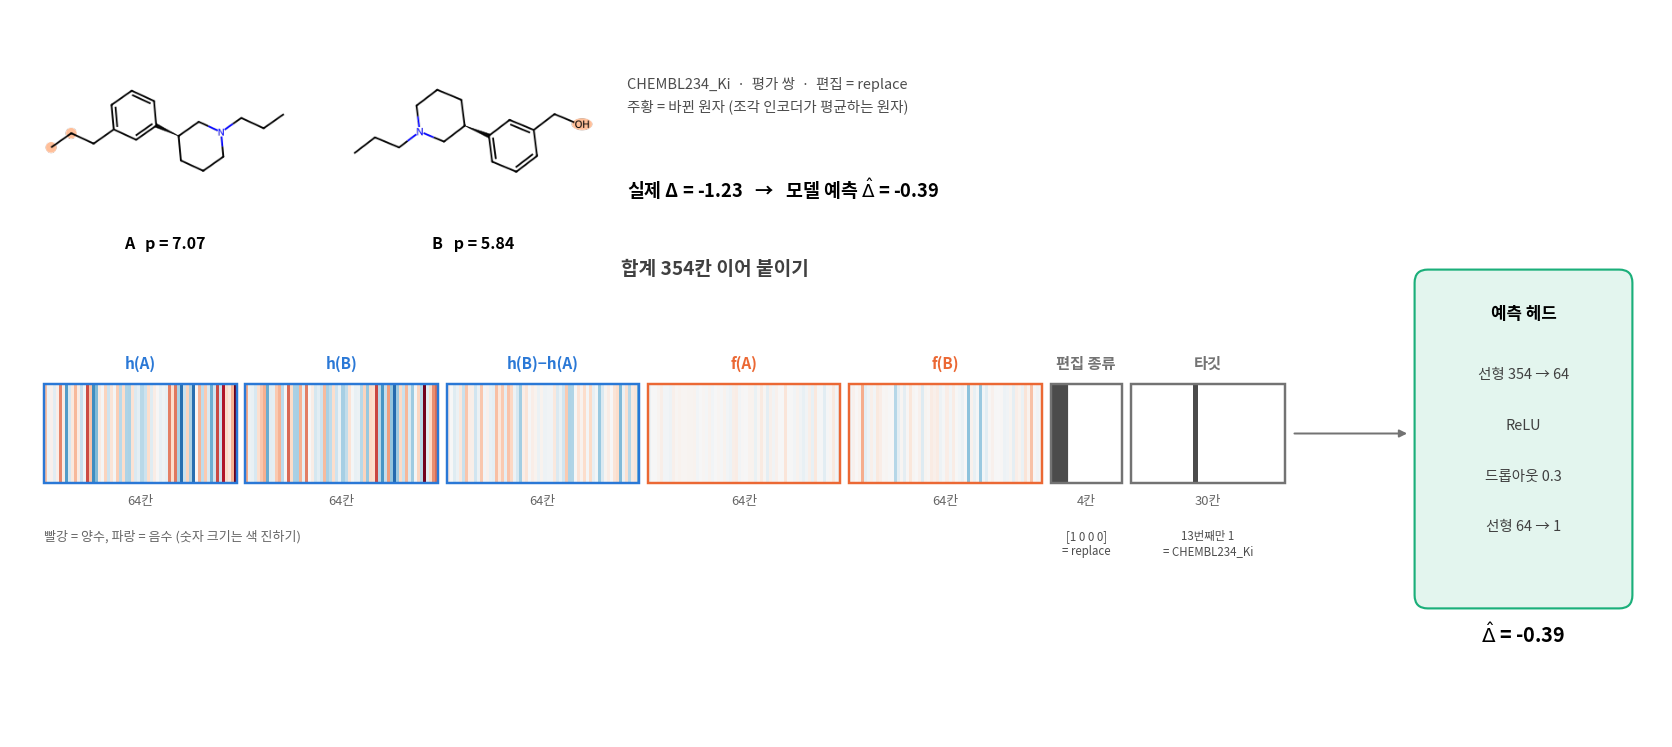

In [23]:
# 이어 붙이기 예시: 실제 평가 쌍 하나를 학습된 쌍 모델(유사 쌍 전부, α=0, 시드 0)에 넣었을 때의 354칸
import io
from matplotlib.patches import FancyBboxPatch
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

_cand = pairs[(pairs.split == 'test') & (pairs.edit == 'replace') & pairs.is_cliff
              & (pairs.smiles_a.str.len() < 40) & (pairs.smiles_b.str.len() < 40)
              & (pairs.atoms_a.map(len).between(1, 3)) & (pairs.atoms_b.map(len).between(1, 3))]   # 작은 치환기 교체만
ex = _cand.sample(1, random_state=3).iloc[0]

_m = PairModel().to(DEVICE)
_m.load_state_dict(torch.load(f'{RUNS}/gnn_a0_{TAGS["all"]}_seed{SEEDS[0]}.pt', map_location=DEVICE)); _m.eval()
with torch.no_grad():
    ga, gb, e, t, _ = collate(samples(pd.DataFrame([ex])))
    ga, gb, e, t = ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE)
    ha, hb = global_mean_pool(_m.mol(ga), ga.batch), global_mean_pool(_m.mol(gb), gb.batch)
    fa, fb = masked_mean(_m.frag(ga), ga), masked_mean(_m.frag(gb), gb)
    parts = [ha, hb, hb - ha, fa, fb, F.one_hot(e, len(EDITS)).float(), F.one_hot(t, len(DEV_TARGETS)).float()]
    vec = torch.cat(parts, 1)[0].cpu().numpy()
    pred = _m.head(torch.cat(parts, 1)).item()
    hidden = _m.head[1](_m.head[0](torch.cat(parts, 1)))[0].cpu().numpy()

def _img(smi, hl, size=300):
    mol = Chem.MolFromSmiles(smi); rdDepictor.Compute2DCoords(mol)
    d = rdMolDraw2D.MolDraw2DCairo(size, int(size * 0.75))
    d.drawOptions().clearBackground = False
    d.DrawMolecule(mol, highlightAtoms=hl, highlightAtomColors={i: (1, .75, .6) for i in hl}, highlightBonds=[])
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig = plt.figure(figsize=(15, 6.6))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 150); ax.set_ylim(4, 70); ax.axis('off')
ax.imshow(_img(ex.smiles_a, ex.atoms_a), extent=(2, 26, 50, 68), zorder=2)
ax.imshow(_img(ex.smiles_b, ex.atoms_b), extent=(30, 54, 50, 68), zorder=2)
ax.text(14, 49.5, f'A   p = {ex.p_a:.2f}', ha='center', va='top', fontsize=10.5, weight='bold')
ax.text(42, 49.5, f'B   p = {ex.p_b:.2f}', ha='center', va='top', fontsize=10.5, weight='bold')
ax.text(56, 64, f'{ex.target}  ·  평가 쌍  ·  편집 = {ex.edit}\n주황 = 바뀐 원자 (조각 인코더가 평균하는 원자)',
        fontsize=9.5, color='0.3', va='top', linespacing=1.6)
ax.text(56, 55, f'실제 Δ = {ex.delta:+.2f}   →   모델 예측 Δ̂ = {pred:+.2f}'.replace('Δ̂', r'$\hat{\Delta}$'),
        fontsize=12, weight='bold', va='top')

# 354칸 막대: 칸 너비를 조각 크기에 비례시키되 원-핫 부분은 보이게 넓힌다
SEG = [('h(A)', 64, C1), ('h(B)', 64, C1), ('h(B)−h(A)', 64, C1), ('f(A)', 64, C2), ('f(B)', 64, C2),
       ('편집 종류', len(EDITS), '0.45'), ('타깃', len(DEV_TARGETS), '0.45')]
x, y0, H, start = 3.0, 27, 9, 0
lim = np.abs(vec[:5 * HIDDEN]).max()
for name, n, c in SEG:
    w = 17.5 if n == HIDDEN else (6.5 if n == len(EDITS) else 14)
    seg = vec[start:start + n]
    if n == HIDDEN:
        ax.imshow(seg[None, :], extent=(x, x + w, y0, y0 + H), cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto', zorder=2)
    else:
        ax.imshow(seg[None, :], extent=(x, x + w, y0, y0 + H), cmap='Greys', vmin=0, vmax=1.3, aspect='auto', zorder=2)
        for k in range(n + 1):
            ax.plot([x + w * k / n] * 2, [y0, y0 + H], color='white', lw=0.6, zorder=3)
    ax.add_patch(plt.Rectangle((x, y0), w, H, fill=False, ec=c, lw=1.6, zorder=4))
    ax.text(x + w / 2, y0 + H + 1.2, f'{name}', ha='center', va='bottom', fontsize=10, weight='bold', color=c)
    ax.text(x + w / 2, y0 - 1.0, f'{n}칸', ha='center', va='top', fontsize=8.5, color='0.4')
    if name == '편집 종류':
        ax.text(x + w / 2, y0 - 4.2, '[' + ' '.join(str(int(v)) for v in seg) + ']\n= ' + EDITS[int(seg.argmax())],
                ha='center', va='top', fontsize=7.5, color='0.3')
    if name == '타깃':
        ax.text(x + w / 2, y0 - 4.2, f'{int(seg.argmax()) + 1}번째만 1\n= {ex.target}', ha='center', va='top', fontsize=7.5, color='0.3')
    x += w + 0.8
    start += n
assert start == len(vec)
ax.text(3, y0 - 4.2, '빨강 = 양수, 파랑 = 음수 (숫자 크기는 색 진하기)', fontsize=8.5, color='0.4', va='top')
ax.text(64, 46, f'합계 {len(vec)}칸 이어 붙이기', ha='center', fontsize=12.5, weight='bold', color='0.25')

# 헤드
hx = 128
ax.annotate('', (hx - 0.8, y0 + H / 2), (x - 0.2, y0 + H / 2), arrowprops=dict(arrowstyle='-|>', color='0.45', lw=1.3))
ax.add_patch(FancyBboxPatch((hx, 16), 19, 30, boxstyle='round,pad=0.4,rounding_size=1.2', fc=(*plt.matplotlib.colors.to_rgb(C3), .12), ec=C3, lw=1.4))
ax.text(hx + 9.5, 42, '예측 헤드', ha='center', fontsize=11, weight='bold')
for k, s in enumerate([f'선형 {len(vec)} → {HIDDEN}', 'ReLU', f'드롭아웃 {DROPOUT}', f'선형 {HIDDEN} → 1']):
    ax.text(hx + 9.5, 36.5 - k * 4.6, s, ha='center', fontsize=9.5, color='0.25')
ax.text(hx + 9.5, 12.5, r'$\hat{\Delta}$' + f' = {pred:+.2f}', ha='center', fontsize=13, weight='bold')
plt.show()

### 비교군: 분자별 GNN

SVR처럼 **분자 하나씩** 약효를 예측한 뒤 두 값을 뺀다. 인코더는 쌍 모델과 **구조가 똑같은 GINE**이고,
가중치는 가져오지 않고 **처음부터 따로 학습**한다. 입력만 다르다.
이것과 쌍 모델(α=0)을 비교하면 **쌍으로 넣는 것 자체가 도움이 되는지** 알 수 있다.


In [24]:
class MolModel(nn.Module):
    """비교군: 분자 하나 + 타깃 → 약효. 인코더(GNN)와 헤드 크기는 쌍 모델과 같다"""
    def __init__(self):
        super().__init__()
        self.mol = GNN()
        self.head = nn.Sequential(nn.Linear(HIDDEN + len(DEV_TARGETS), HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(HIDDEN, 1))

    def forward(self, g, tgt):
        h = global_mean_pool(self.mol(g), g.batch)
        return self.head(torch.cat([h, F.one_hot(tgt, len(DEV_TARGETS)).float()], 1)).squeeze(1)

MOL_PATIENCE = 20   # 한 epoch에 보는 양이 쌍보다 훨씬 적어 쌍 모델(8)보다 길게 기다린다
# 분자는 3.1만 개라 epoch당 학습 횟수가 쌍(13.5만~70만)보다 훨씬 적다. 200에서는 시드 3개 모두
# 상한에 걸려 멈췄다(최적 197~199) → 상한을 넉넉히 두고 patience로 멈춘다
MOL_EPOCHS = 1000
MOLS = pd.concat([load(t).assign(target=t, k=np.arange(len(load(t)))) for t in DEV_TARGETS], ignore_index=True)

def mol_collate(batch):
    g, t, y = zip(*batch)
    return Batch.from_data_list(g), torch.tensor(t), torch.tensor(y, dtype=torch.float32)

def mol_loader(df, shuffle=False):
    items = [(graphs[t, k], DEV_TARGETS.index(t), p) for t, k, p in zip(df.target, df.k, df.p)]
    if shuffle:   # 학습용: 쌍 모델처럼 일꾼 8개
        return DataLoader(items, BATCH, shuffle=True, collate_fn=mol_collate, num_workers=8, persistent_workers=True)
    return DataLoader(items, 1024, collate_fn=mol_collate)

def mol_predict(model, loader):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(g.to(DEVICE), t.to(DEVICE)).cpu() for g, t, _ in loader]).numpy()

def train_mol(seed, tag):
    """쌍 모델 가중치는 쓰지 않고 새로 학습한다. 파일 이름도 따로라 캐시가 섞이지 않는다"""
    path, hist_path = f'{RUNS}/gnnmol_{tag}_seed{seed}.pt', f'{RUNS}/histmol_{tag}_seed{seed}.csv'
    torch.manual_seed(seed)
    model = MolModel().to(DEVICE)
    if os.path.exists(path) and os.path.exists(hist_path):
        model.load_state_dict(torch.load(path))
        return model
    tr, va = MOLS[MOLS.split == 'train'], MOLS[MOLS.split == 'val']
    tr_loader, va_loader = mol_loader(tr, shuffle=True), mol_loader(va)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    best, best_state, wait, hist = float('inf'), None, 0, []
    for epoch in range(MOL_EPOCHS):
        model.train()
        for g, t, y in tr_loader:
            g, t, y = g.to(DEVICE), t.to(DEVICE), y.to(DEVICE)
            loss = ((model(g, t) - y) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        score = rmse(mol_predict(model, va_loader), va.p)
        hist.append(dict(epoch=epoch, val=score))
        if score < best:
            best, wait = score, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if epoch % 25 == 0 or wait >= MOL_PATIENCE:
            log(f'mol s={seed} epoch={epoch} val_rmse(분자)={score:.3f} best={best:.3f}')
        if wait >= MOL_PATIENCE:
            break
    model.load_state_dict(best_state)
    log(f'mol s={seed} 멈춤 epoch={epoch} (최적 {int(np.argmin([h["val"] for h in hist]))})')
    pd.DataFrame(hist).to_csv(hist_path, index=False)
    torch.save(best_state, path)
    return model

MOL_TAG = f't{len(DEV_TARGETS)}_h{HIDDEN}_l{LAYERS}_dr{DROPOUT}_wd{WD}_ep{MOL_EPOCHS}'
log(f'[mol] 학습 분자 {(MOLS.split == "train").sum():,} | 검증 분자 {(MOLS.split == "val").sum():,}')
te = (MOLS.split == 'test').values
files = [f'{RUNS}/{k}_{MOL_TAG}_seed{s}.{x}' for s in SEEDS for k, x in [('gnnmol', 'pt'), ('histmol', 'csv')]]
cache = pred_cache('preds_mol', MOL_TAG, files)
if cache and os.path.exists(cache):
    MOL_PRED = pd.read_pickle(cache)
    assert (MOL_PRED[['target', 'k']].values == MOLS[['target', 'k']].values).all(), '분자 순서가 캐시와 다르다'
    log(f'[mol] 예측값 캐시 사용: {os.path.basename(cache)}')
else:
    all_loader = mol_loader(MOLS)
    MOL_PRED = MOLS[['target', 'k']].copy()
    for s in SEEDS:
        MOL_PRED[f's{s}'] = mol_predict(train_mol(s, MOL_TAG), all_loader)
    save_cache(pred_cache('preds_mol', MOL_TAG, files), MOL_PRED)
for s in SEEDS:
    p_ = MOL_PRED[f's{s}'].values
    print(f'시드 {s}: 분자 단위 test RMSE {rmse(p_[te], MOLS.p[te]):.3f}')
    p_ = dict(zip(zip(MOLS.target, MOLS.k), p_))
    for pset in RESULTS.values():
        pset[f'pred_gnnmol_s{s}'] = [p_[t, j] - p_[t, i] for t, i, j in zip(pset.target, pset.i, pset.j)]
for pset in RESULTS.values():
    pset['pred_gnnmol'] = pset[f'pred_gnnmol_s{SEEDS[0]}']
print(f'참고: SVR 분자 단위 test RMSE {rmse(np.concatenate([mol_pred[t][load(t).split == "test"] for t in DEV_TARGETS]), MOLS.p[te]):.3f}')

[mol] 학습 분자 31,144 | 검증 분자 7,768
[mol] 예측값 캐시 사용: preds_mol_t30_h64_l3_dr0.3_wd0.0001_ep1000_1790834439.pkl
시드 0: 분자 단위 test RMSE 0.828


시드 1: 분자 단위 test RMSE 0.821


시드 2: 분자 단위 test RMSE 0.820


참고: SVR 분자 단위 test RMSE 0.691


In [25]:
# 학습 기록 (runs/train.log). 가중치가 캐시된 경우 이 셀이 실제 학습 과정을 보여준다
print(open(f'{RUNS}/train.log').read()[-3000:])

:53 t30_h6 a=0.5 s=2 epoch=0 val_rmse=0.956 val_cliff=1.541 best=0.956
10-03 07:36:45 t30_h6 a=4 s=2 epoch=10 val_rmse=0.792 val_cliff=1.101 best=0.792
10-03 07:39:00 t30_h6 a=0.5 s=2 epoch=5 val_rmse=0.792 val_cliff=1.174 best=0.792
10-03 07:52:31 t30_h6 a=4 s=2 epoch=15 val_rmse=0.782 val_cliff=1.058 best=0.776
10-03 07:55:00 t30_h6 a=0.5 s=2 epoch=10 val_rmse=0.742 val_cliff=1.069 best=0.742
10-03 08:08:25 t30_h6 a=4 s=2 epoch=20 val_rmse=0.752 val_cliff=1.024 best=0.752
10-03 08:11:01 t30_h6 a=0.5 s=2 epoch=15 val_rmse=0.738 val_cliff=1.026 best=0.735
10-03 08:24:17 t30_h6 a=4 s=2 epoch=25 val_rmse=0.754 val_cliff=1.003 best=0.747
10-03 08:27:14 t30_h6 a=0.5 s=2 epoch=20 val_rmse=0.725 val_cliff=1.020 best=0.723
10-03 08:40:09 t30_h6 a=4 s=2 epoch=30 val_rmse=0.756 val_cliff=1.007 best=0.737
10-03 08:43:22 t30_h6 a=0.5 s=2 epoch=25 val_rmse=0.718 val_cliff=1.015 best=0.718
10-03 08:56:03 t30_h6 a=4 s=2 epoch=35 val_rmse=0.746 val_cliff=0.984 best=0.737
10-03 08:59:26 t30_h6 a=0.5 s

## 10. 결과 비교

α와 시드(무작위 시작점)를 바꿔가며 학습한 결과를 비교 대상과 비교한다.

In [26]:
LABEL = {'single': '한 군데만 다른 쌍', 'all': '유사 쌍 전부'}

def seed_rmse(df, a, mask=None):
    """시드 3개의 RMSE를 배열로. a='mol'이면 분자별 GNN"""
    d = df if mask is None else df[mask]
    col = 'pred_gnnmol_s{}' if a == 'mol' else f'pred_gnn_a{a}_s{{}}'
    return np.array([rmse(d[col.format(s)], d.delta) for s in SEEDS])

ALPHA_TABLES, BEST = {}, {}
for st, pset in RESULTS.items():
    v = pset[pset.split.str.startswith('val')]
    at = pd.DataFrame({str(a): {'val cliff': seed_rmse(v, a, v.is_cliff).mean(),
                                'val non-cliff': seed_rmse(v, a, ~v.is_cliff).mean(),
                                'val all': seed_rmse(v, a).mean()} for a in ALPHAS}).T.rename_axis('alpha')
    ALPHA_TABLES[st], BEST[st] = at, at['val cliff'].idxmin()
    for a in ALPHAS:
        pset[f'pred_gnn_a{a}'] = pset[f'pred_gnn_a{a}_s{SEEDS[0]}']
    pset['pred_gnn_best'] = pset[f'pred_gnn_a{BEST[st]}_s{SEEDS[0]}']
    pset['pred_gnn_best_fwd'] = pset[f'pred_gnn_a{BEST[st]}_fwd']
    log(f'[{st}] best alpha = {BEST[st]}')

[single] best alpha = 4


[all] best alpha = 1


### 모델 비교

같은 조건에서 시드만 바꿔 3번 학습했다. **막대 위 수염이 그 흔들림**이고,
모델 간 차이가 이 폭보다 커야 의미가 있다.
노란 점선은 분자별 GNN의 높이다. 쌍 GNN 막대가 점선보다 낮으면 **쌍으로 넣는 쪽이 낫다**는 뜻이다
(가중치 없이 학습한 분자별 GNN과 공정하게 비교할 상대는 α=0).

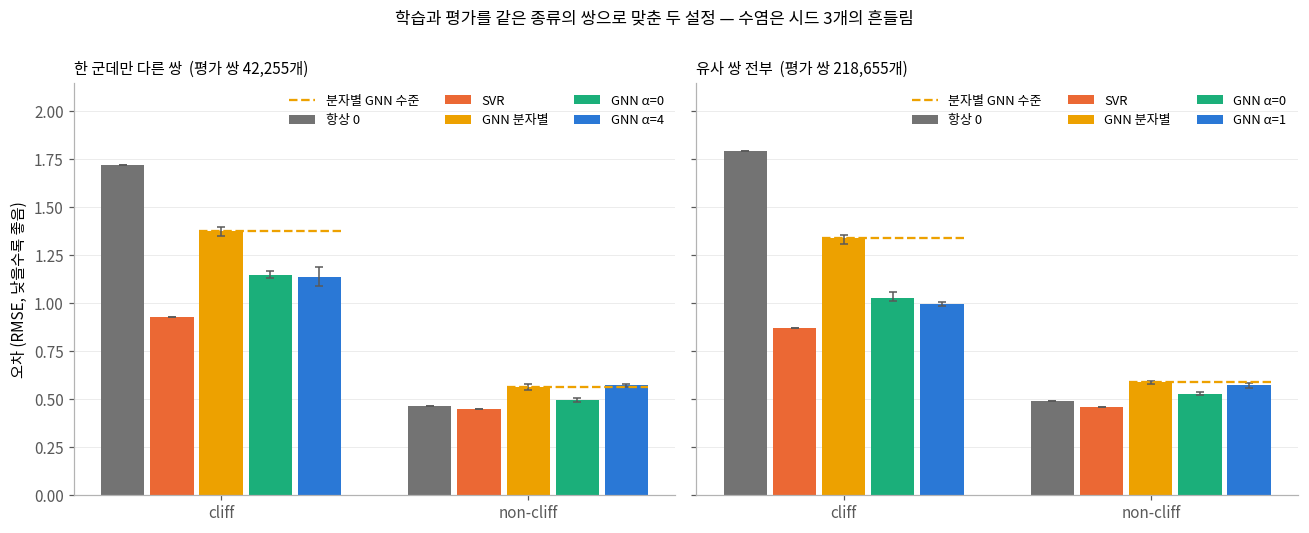

In [27]:
GROUPS = [('test', True, 'cliff'), ('test', False, 'non-cliff')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for a_, (st, pset) in zip(axes, RESULTS.items()):
    bars = [('base', 'zero', MUTED, '항상 0'), ('base', 'svr', C2, 'SVR'), ('gnn', 'mol', C4, 'GNN 분자별'),
            ('gnn', 0, C3, 'GNN α=0'), ('gnn', BEST[st], C1, f'GNN α={BEST[st]}')]
    w = 0.16
    for k_, (kind, key, col, lbl) in enumerate(bars):
        v, lo, hi = [], [], []
        for sp, cl, _ in GROUPS:
            d = pset[pset.split == sp]
            m = d.is_cliff if cl else ~d.is_cliff
            if kind == 'base':
                v.append(rmse(d[m][f'pred_{key}'], d[m].delta)); lo.append(0); hi.append(0)
            else:
                s = seed_rmse(d, key, m)
                v.append(s.mean()); lo.append(s.mean() - s.min()); hi.append(s.max() - s.mean())
        a_.bar(np.arange(len(GROUPS)) + (k_ - 2) * w, v, w * 0.88, color=col, label=lbl, zorder=2,
               yerr=[lo, hi], capsize=2.5, error_kw=dict(elinewidth=1, ecolor='0.35'))
        if key == 'mol':
            mol_v = v
    for g_, mv in enumerate(mol_v):   # 분자별 GNN 높이를 쌍 GNN 막대 위로 연장 → 점선보다 낮으면 쌍 입력이 낫다
        a_.hlines(mv, g_ - w * 0.44, g_ + 2 * w + w * 0.44, colors=C4, linestyles='--', lw=1.5, zorder=3,
                  label='분자별 GNN 수준' if g_ == 0 else None)
    a_.set(xticks=range(len(GROUPS)), ylim=(0, 2.15))
    a_.set_xticklabels([g[2] for g in GROUPS], fontsize=10)
    a_.set_title(f'{LABEL[st]}  (평가 쌍 {len(pset[pset.split.str.startswith("test")]):,}개)', loc='left', fontsize=10)
    a_.legend(fontsize=8.5, frameon=False, ncol=3)   # α가 설정마다 달라 패널마다 따로 단다
    a_.grid(axis='x', visible=False); tidy(a_)
axes[0].set_ylabel('오차 (RMSE, 낮을수록 좋음)')
fig.suptitle('학습과 평가를 같은 종류의 쌍으로 맞춘 두 설정 — 수염은 시드 3개의 흔들림', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

In [28]:
MODELS = ['zero', 'svr', 'gnnmol', 'gnn_a0', 'gnn_best']
display(pd.concat({LABEL[st]: pd.concat({m: rmse_table(pset, f'pred_{m}').loc[['test']]
                                         for m in MODELS}, axis=1)
                   for st, pset in RESULTS.items()}).round(3))
for st, pset in RESULTS.items():
    t_ = pset[pset.split.str.startswith('test')]
    d_ = rmse(t_.pred_gnn_best_fwd, t_.delta) - rmse(t_.pred_gnn_best, t_.delta)
    print(f'{LABEL[st]}: 양방향 평균 효과 {d_:+.3f} (거의 0 — 학습 때 이미 양방향을 보여줬기 때문)')

zero                     svr                  gnnmol  \
is_cliff          cliff non-cliff    all  cliff non-cliff    all  cliff   
           split                                                          
한 군데만 다른 쌍 test   1.720     0.465  0.910  0.928     0.447  0.590  1.397   
유사 쌍 전부    test   1.796     0.490  1.034  0.872     0.459  0.603  1.356   

                                  gnn_a0                  gnn_best            \
is_cliff         non-cliff    all  cliff non-cliff    all    cliff non-cliff   
           split                                                               
한 군데만 다른 쌍 test      0.563  0.826  1.134     0.486  0.686    1.091     0.565   
유사 쌍 전부    test      0.591  0.873  1.060     0.521  0.713    0.988     0.586   

                         
is_cliff            all  
           split         
한 군데만 다른 쌍 test   0.717  
유사 쌍 전부    test   0.721

한 군데만 다른 쌍: 양방향 평균 효과 +0.005 (거의 0 — 학습 때 이미 양방향을 보여줬기 때문)
유사 쌍 전부: 양방향 평균 효과 +0.003 (거의 0 — 학습 때 이미 양방향을 보여줬기 때문)


### 기준 분자로 개별 활성 추정

Δ만 맞히고 분자 각각은 엉뚱하게 보는 것은 아닌지 확인한다.
평가 분자 B마다 짝이 되는 **학습 분자 A의 실측값**을 기준으로 B의 활성을 추정한다.

p̂(B) = 평균[ p(A) + Δ̂(A→B) ]   (B와 짝인 학습 분자 A 전부)

- 같은 평가 분자에서 **바로 예측**(SVR, GNN 분자별)과 비교한다
- **기준별 흩어짐**: 기준 A를 바꿔도 B의 추정값이 비슷한지 (기준 2개 이상인 분자의 표준편차 중앙값)
- 짝이 되는 학습 분자가 없는 평가 분자는 추정할 수 없어 뺀다 (추정 가능 비율을 함께 표시)


[single] 추정 가능 평가 분자 7,496/9,802 (76%) | 기준 2개 이상 5,651


[all] 추정 가능 평가 분자 9,148/9,802 (93%) | 기준 2개 이상 8,703


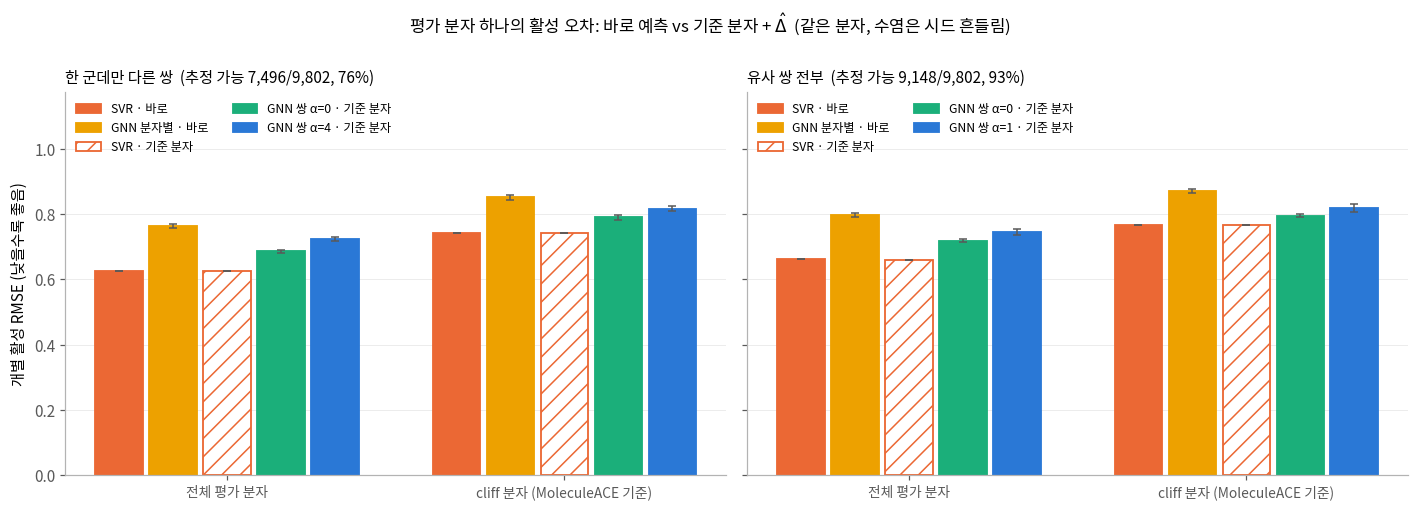

전체 분자  cliff 분자  기준별 흩어짐
한 군데만 다른 쌍 SVR · 바로           0.625     0.741      NaN
           GNN 분자별 · 바로       0.763     0.851      NaN
           SVR · 기준 분자        0.626     0.741    0.101
           GNN 쌍 α=0 · 기준 분자  0.686     0.789    0.339
           GNN 쌍 α=4 · 기준 분자  0.723     0.815    0.391
유사 쌍 전부    SVR · 바로           0.661     0.765      NaN
           GNN 분자별 · 바로       0.795     0.870      NaN
           SVR · 기준 분자        0.660     0.765    0.100
           GNN 쌍 α=0 · 기준 분자  0.718     0.794    0.400
           GNN 쌍 α=1 · 기준 분자  0.745     0.818    0.400

In [29]:
# 평가 분자 B의 활성을 학습 분자 A(실측값을 앎)를 기준으로 추정: p̂(B) = p(A) + Δ̂(A→B), 기준이 여러 개면 평균
TEST = pd.concat([load(t).assign(target=t, k=np.arange(len(load(t))))[lambda d: d.split == 'test'] for t in DEV_TARGETS]) \
         .set_index(['target', 'k'])[['p', 'cliff_mol']]
P_TRUE = {t: load(t).p.values for t in DEV_TARGETS}
SVR_DIRECT = pd.concat({t: pd.Series(mol_pred[t].values) for t in DEV_TARGETS}).rename_axis(['target', 'k'])
MOL_DIRECT = MOL_PRED.set_index(['target', 'k'])

def anchored(pset, col):
    """평가 쌍(평가 분자 – 학습 분자)으로 평가 분자마다 (평균 추정값, 기준별 표준편차, 기준 수)"""
    e = pset[pset.split == 'test']
    b_is_j = np.array([mol_split[t][i] != 'test' for t, i in zip(e.target, e.i)])   # 쌍의 어느 쪽이 평가 분자인가
    k_test, k_ref = np.where(b_is_j, e.j, e.i), np.where(b_is_j, e.i, e.j)
    p_ref = np.array([P_TRUE[t][k] for t, k in zip(e.target, k_ref)])
    est = p_ref + np.where(b_is_j, 1, -1) * e[col].values      # 열의 Δ̂는 i → j 방향
    return pd.DataFrame({'target': e.target.values, 'k': k_test, 'est': est}) \
             .groupby(['target', 'k']).est.agg(['mean', 'std', 'size'])

ANCHOR = {}
for st, pset in RESULTS.items():
    est = {'SVR · 기준 분자': [anchored(pset, 'pred_svr')],
           'GNN 쌍 α=0 · 기준 분자': [anchored(pset, f'pred_gnn_a0_s{s}') for s in SEEDS],
           f'GNN 쌍 α={BEST[st]} · 기준 분자': [anchored(pset, f'pred_gnn_a{BEST[st]}_s{s}') for s in SEEDS]}
    idx = est['SVR · 기준 분자'][0].index                     # 추정 가능한 평가 분자 (모든 모델 공통)
    truth = TEST.loc[idx]
    cl = (truth.cliff_mol == 1).values
    preds = {'SVR · 바로': [SVR_DIRECT.loc[idx].values],
             'GNN 분자별 · 바로': [MOL_DIRECT.loc[idx, f's{s}'].values for s in SEEDS]}
    preds.update({m: [r.loc[idx, 'mean'].values for r in rs] for m, rs in est.items()})
    rows = {}
    for m, ps in preds.items():
        a_ = [rmse(p, truth.p) for p in ps]
        c_ = [rmse(p[cl], truth.p.values[cl]) for p in ps]
        sd = [float(r.loc[idx].query('size >= 2')['std'].median()) for r in est[m]] if m in est else [np.nan]
        rows[m] = {'전체 분자': np.mean(a_), '전체 분자 폭': np.ptp(a_), 'cliff 분자': np.mean(c_), 'cliff 분자 폭': np.ptp(c_),
                   '기준별 흩어짐': np.mean(sd)}
    ANCHOR[st] = dict(table=pd.DataFrame(rows).T, n=len(idx), n_test=len(TEST), idx=idx, truth=truth, preds=preds,
                      n_ref=est['SVR · 기준 분자'][0].loc[idx, 'size'],
                      n_multi=int((est['SVR · 기준 분자'][0].loc[idx, 'size'] >= 2).sum()))
    log(f'[{st}] 추정 가능 평가 분자 {len(idx):,}/{len(TEST):,} ({len(idx)/len(TEST):.0%}) | 기준 2개 이상 {ANCHOR[st]["n_multi"]:,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
style = {'SVR · 바로': (C2, ''), 'GNN 분자별 · 바로': (C4, ''), 'SVR · 기준 분자': (C2, '//'),
         'GNN 쌍 α=0 · 기준 분자': (C3, ''), 'GNN 쌍 best · 기준 분자': (C1, '')}
for a_, (st, res) in zip(axes, ANCHOR.items()):
    t_ = res['table'].rename(index={f'GNN 쌍 α={BEST[st]} · 기준 분자': 'GNN 쌍 best · 기준 분자'})
    w = 0.16
    for k_, (m, (col, hatch)) in enumerate(style.items()):
        v = [t_.loc[m, '전체 분자'], t_.loc[m, 'cliff 분자']]
        e = [t_.loc[m, '전체 분자 폭'] / 2, t_.loc[m, 'cliff 분자 폭'] / 2]
        lbl = m.replace('best', f'α={BEST[st]}')
        a_.bar(np.arange(2) + (k_ - 2) * w, v, w * 0.88, color=col if not hatch else SURFACE, edgecolor=col,
               hatch=hatch, linewidth=1.2, label=lbl, zorder=2, yerr=e, capsize=2.5, error_kw=dict(elinewidth=1, ecolor='0.35'))
    a_.set(xticks=range(2))
    a_.set_xticklabels(['전체 평가 분자', 'cliff 분자 (MoleculeACE 기준)'], fontsize=9)
    a_.set_title(f'{LABEL[st]}  (추정 가능 {res["n"]:,}/{res["n_test"]:,}, {res["n"]/res["n_test"]:.0%})', loc='left', fontsize=10)
    a_.legend(fontsize=8, frameon=False, ncol=2, loc='upper left'); a_.grid(axis='x', visible=False); tidy(a_)
axes[0].set_ylabel('개별 활성 RMSE (낮을수록 좋음)')
axes[0].set_ylim(0, max(r['table'][['전체 분자', 'cliff 분자']].values.max() for r in ANCHOR.values()) * 1.35)
fig.suptitle(r'평가 분자 하나의 활성 오차: 바로 예측 vs 기준 분자 + $\hat{\Delta}$  (같은 분자, 수염은 시드 흔들림)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()
display(pd.concat({LABEL[st]: r['table'].drop(columns=['전체 분자 폭', 'cliff 분자 폭']) for st, r in ANCHOR.items()}).round(3))

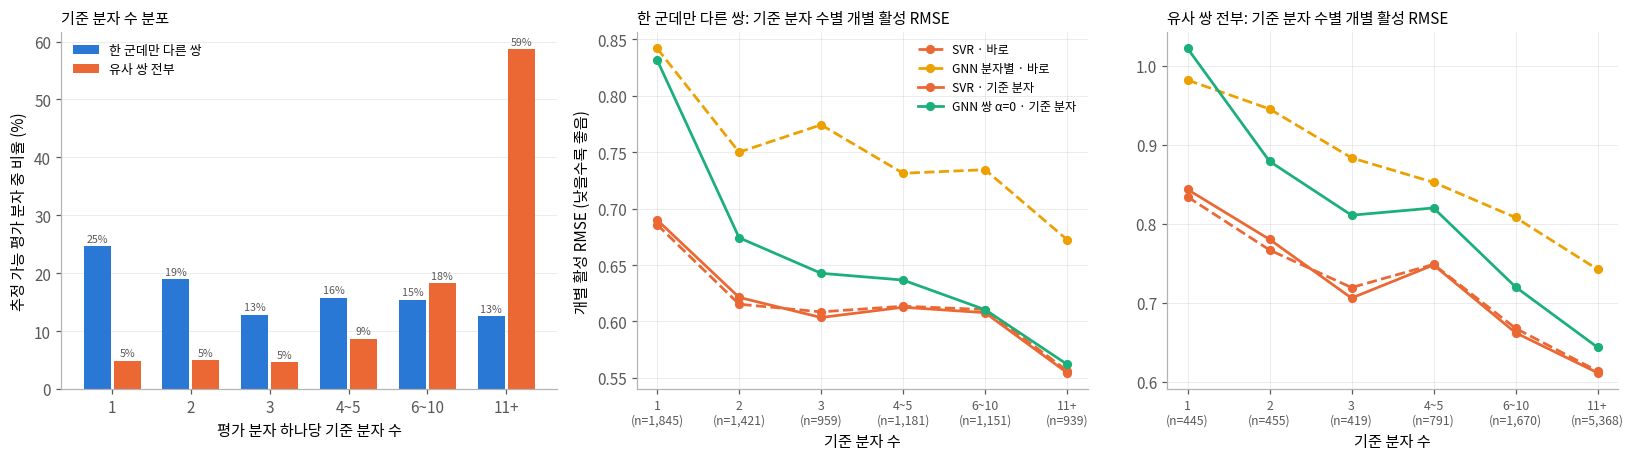

In [30]:
# 기준 분자 수 분포(왼쪽)와 기준 분자 수별 개별 활성 오차(가운데·오른쪽)
BINS = [(1, 1, '1'), (2, 2, '2'), (3, 3, '3'), (4, 5, '4~5'), (6, 10, '6~10'), (11, 10 ** 9, '11+')]
def ref_bin(n):
    return pd.Series(pd.cut(n, [b[0] - 0.5 for b in BINS] + [10 ** 9], labels=[b[2] for b in BINS]), index=n.index)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), gridspec_kw=dict(width_ratios=[1.1, 1, 1]))
a_ = axes[0]; w = 0.38
for k_, (st, res) in enumerate(ANCHOR.items()):
    share = ref_bin(res['n_ref']).value_counts(normalize=True).reindex([b[2] for b in BINS]) * 100
    bars = a_.bar(np.arange(len(BINS)) + (k_ - 0.5) * w, share.values, w * 0.9, color=[C1, C2][k_], label=LABEL[st], zorder=2)
    for b, v in zip(bars, share.values):
        a_.text(b.get_x() + b.get_width() / 2, v + 0.8, f'{v:.0f}%', ha='center', fontsize=7, color='0.35')
a_.set(xticks=range(len(BINS)), xlabel='평가 분자 하나당 기준 분자 수', ylabel='추정 가능 평가 분자 중 비율 (%)')
a_.set_xticklabels([b[2] for b in BINS])
a_.set_title('기준 분자 수 분포', loc='left', fontsize=10)
a_.legend(fontsize=8.5, frameon=False); a_.grid(axis='x', visible=False); tidy(a_)

LINES = [('SVR · 바로', C2, '--'), ('GNN 분자별 · 바로', C4, '--'), ('SVR · 기준 분자', C2, '-'), ('GNN 쌍 α=0 · 기준 분자', C3, '-')]
for a_, (st, res) in zip(axes[1:], ANCHOR.items()):
    bins = ref_bin(res['n_ref']).values
    tp = res['truth'].p.values
    for m, col, ls in LINES:
        ys = [np.mean([rmse(p[bins == b[2]], tp[bins == b[2]]) for p in res['preds'][m]]) for b in BINS]
        a_.plot(range(len(BINS)), ys, ls, color=col, marker='o', ms=5, lw=1.8, label=m)
    a_.set(xticks=range(len(BINS)), xlabel='기준 분자 수')
    a_.set_xticklabels([f'{b[2]}\n(n={int((bins == b[2]).sum()):,})' for b in BINS], fontsize=8)
    a_.set_title(f'{LABEL[st]}: 기준 분자 수별 개별 활성 RMSE', loc='left', fontsize=10)
    tidy(a_)
axes[1].set_ylabel('개별 활성 RMSE (낮을수록 좋음)'); axes[1].legend(fontsize=8, frameon=False)
fig.tight_layout(); plt.show()

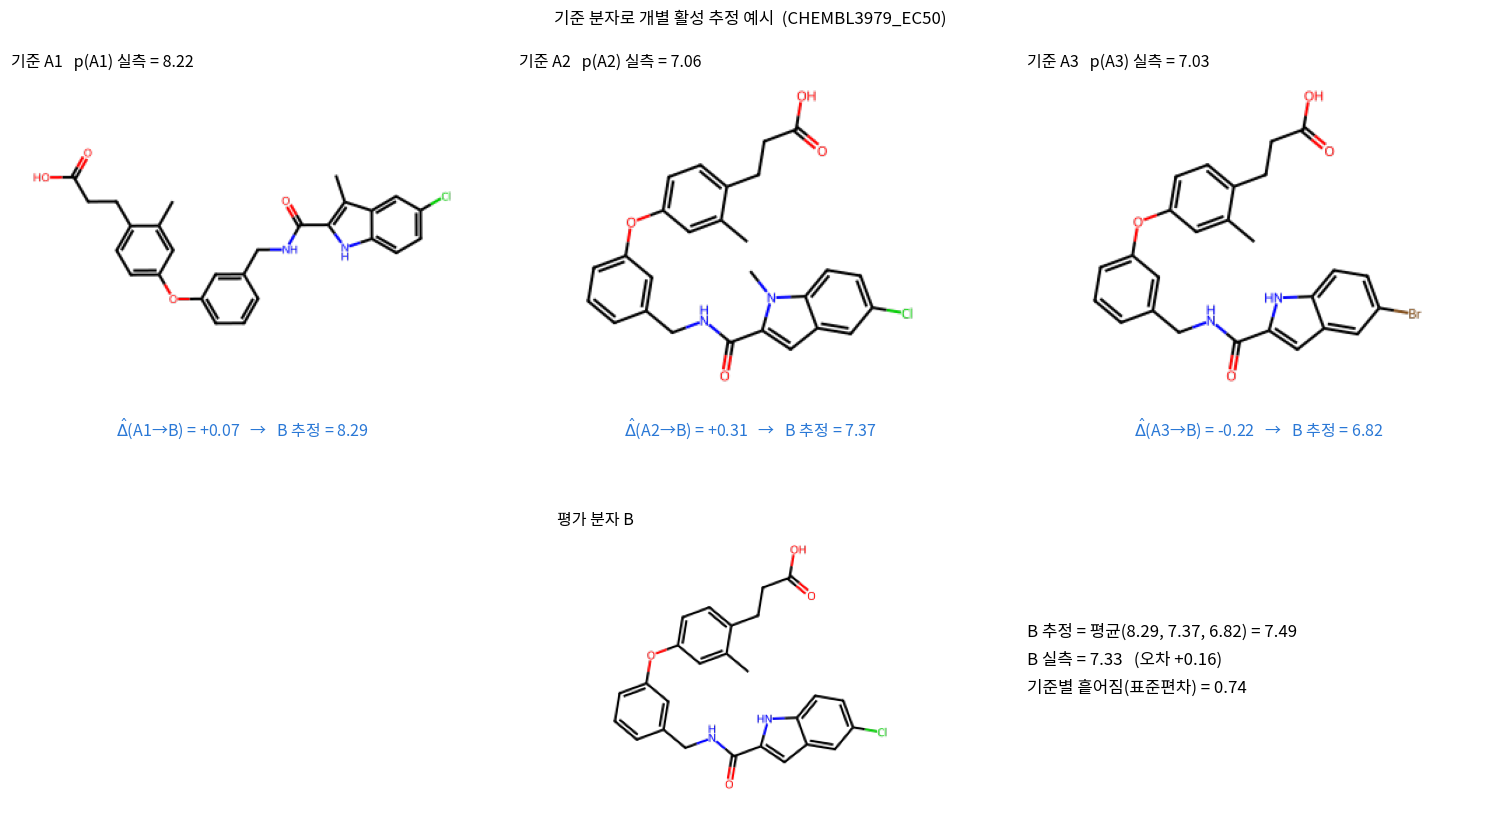

In [31]:
# 기준 분자 예시: 기준이 3개인 평가 분자 하나 (한 군데만 다른 쌍, GNN 쌍 α=0, 시드 0)
import io
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def _mol(smiles, size=(330, 230)):
    m = Chem.MolFromSmiles(smiles); rdDepictor.Compute2DCoords(m)
    d = rdMolDraw2D.MolDraw2DCairo(*size); d.drawOptions().clearBackground = False
    d.DrawMolecule(m); d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

ps = RESULTS['single']; e = ps[ps.split == 'test'].copy()
e['b_is_j'] = [mol_split[t][i] != 'test' for t, i in zip(e.target, e.i)]
e['kb'] = np.where(e.b_is_j, e.j, e.i); e['ka'] = np.where(e.b_is_j, e.i, e.j)
e['d_hat'] = np.where(e.b_is_j, 1, -1) * e[f'pred_gnn_a0_s{SEEDS[0]}']
n_ref = e.groupby(['target', 'kb']).size()
t_, kb = n_ref[n_ref == 3].sample(1, random_state=SEED).index[0]
ex = e[(e.target == t_) & (e.kb == kb)]
p_b = P_TRUE[t_][kb]; smi = load(t_).smiles

fig = plt.figure(figsize=(14, 7.2))
ests = []
for n, r in enumerate(ex.itertuples()):
    p_a = P_TRUE[t_][r.ka]; est = p_a + r.d_hat; ests.append(est)
    ax = fig.add_axes([0.02 + n * 0.33, 0.50, 0.30, 0.43]); ax.imshow(_mol(smi[r.ka])); ax.axis('off')
    ax.set_title(f'기준 A{n + 1}   p(A{n + 1}) 실측 = {p_a:.2f}', fontsize=10.5, loc='left')
    ax.text(0.5, -0.06, rf'$\hat{{\Delta}}$(A{n + 1}→B) = {r.d_hat:+.2f}   →   B 추정 = {est:.2f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=10.5, color=C1)
ax = fig.add_axes([0.35, 0.0, 0.30, 0.34]); ax.imshow(_mol(smi[kb])); ax.axis('off')
ax.set_title('평가 분자 B', fontsize=10.5, loc='left')
fig.text(0.68, 0.18, f'B 추정 = 평균({", ".join(f"{v:.2f}" for v in ests)}) = {np.mean(ests):.2f}\n'
                     f'B 실측 = {p_b:.2f}   (오차 {np.mean(ests) - p_b:+.2f})\n'
                     f'기준별 흩어짐(표준편차) = {np.std(ests, ddof=1):.2f}', fontsize=11, va='center', linespacing=1.8)
fig.suptitle(f'기준 분자로 개별 활성 추정 예시  ({t_})', y=1.0, fontsize=11)
plt.show()

#### 기준 분자 평가 해석

| 한 군데만 다른 쌍 (평가 분자 76% 추정 가능) | 전체 분자 | cliff 분자 | 기준별 흩어짐 |
|---|---|---|---|
| SVR · 바로 | **0.625** | **0.741** | — |
| GNN 분자별 · 바로 | 0.763 | 0.851 | — |
| SVR · 기준 분자 | 0.626 | 0.741 | 0.10 |
| GNN 쌍 α=0 · 기준 분자 | 0.686 | 0.789 | 0.34 |

- **Δ만 맞고 개별 값은 엉뚱한 것은 아니다.** 실측 기준을 주면 쌍 GNN이 개별 활성을 0.69 오차로 맞히고,
  같은 인코더로 바로 예측한 분자별 GNN(0.76)보다 낫다
- **그래도 SVR(0.63)보다 못하고, 기준을 바꾸면 추정값이 3배 더 흔들린다** (0.34 vs 0.10).
  비슷한 분자를 SVR만큼 일관되게 보지 못한다는 뜻이다
- **기준 분자가 많을수록 크게 좋아진다** — 기준 1개일 때 0.83, 11개 이상이면 0.56으로 SVR과 비슷해진다

### 누수 점검: 다른 타깃에서 본 분자

GNN은 30개 타깃을 모델 하나로 학습한다. 그래서 어떤 타깃의 평가 분자가 **다른 타깃에서는 학습 분자**였을 수 있다
(평가 분자의 약 1/3). 그 타깃의 활성값을 본 것은 아니지만 구조는 본 셈이다. SVR은 타깃마다 따로 학습해 이 문제가 없다.

In [32]:
# 누수 점검: 30개 타깃을 모델 하나로 학습하므로, 평가 분자가 다른 타깃의 학습 분자로 나왔을 수 있다
TRAIN_T = pd.concat([load(t)[load(t).split == 'train'].assign(target=t) for t in DEV_TARGETS]).groupby('smiles').target.apply(set)
def seen_elsewhere(t, k):
    s = load(t).smiles[k]
    return s in TRAIN_T.index and bool(TRAIN_T[s] - {t})

te_seen = np.array([seen_elsewhere(t, k) for t, k in TEST.index])
print(f'평가 분자 {len(te_seen):,}개 중 다른 타깃의 학습 분자로 나온 분자 {te_seen.sum():,}개 ({te_seen.mean():.1%})')

rows = []
for st, pset in RESULTS.items():
    d = pset[pset.split == 'test']
    kb = np.where([mol_split[t][i] != 'test' for t, i in zip(d.target, d.i)], d.j, d.i)   # 평가 분자 쪽
    seen = np.array([seen_elsewhere(t, k) for t, k in zip(d.target, kb)])
    models = {'항상 0': ['pred_zero'], 'SVR': ['pred_svr'], 'GNN 분자별': [f'pred_gnnmol_s{s}' for s in SEEDS],
              'GNN 쌍 α=0': [f'pred_gnn_a0_s{s}' for s in SEEDS], 'GNN 쌍 best': [f'pred_gnn_a{BEST[st]}_s{s}' for s in SEEDS]}
    for cn, cm in [('cliff', d.is_cliff.values), ('non-cliff', ~d.is_cliff.values)]:
        for sn, sm in [('다른 타깃에서 본 분자', seen), ('처음 보는 분자', ~seen)]:
            m = cm & sm
            row = {'설정': f'{LABEL[st]} (best α={BEST[st]})', '구분': cn, '평가 분자': sn, '쌍 수': int(m.sum())}
            row.update({name: np.mean([rmse(d[c].values[m], d.delta.values[m]) for c in cs]) for name, cs in models.items()})
            rows.append(row)
LEAK = pd.DataFrame(rows).set_index(['설정', '구분', '평가 분자'])
LEAK['GNN 쌍 α=0 − SVR'] = LEAK['GNN 쌍 α=0'] - LEAK['SVR']
display(LEAK.round(3))

평가 분자 9,802개 중 다른 타깃의 학습 분자로 나온 분자 3,311개 (33.8%)


쌍 수   항상 0    SVR  GNN 분자별  \
설정                    구분        평가 분자                                        
한 군데만 다른 쌍 (best α=4) cliff     다른 타깃에서 본 분자   2571  1.673  0.954    1.351   
                                처음 보는 분자       6866  1.737  0.918    1.389   
                      non-cliff 다른 타깃에서 본 분자  10995  0.439  0.431    0.525   
                                처음 보는 분자      21823  0.477  0.455    0.581   
유사 쌍 전부 (best α=1)    cliff     다른 타깃에서 본 분자  20610  1.772  0.850    1.276   
                                처음 보는 분자      40064  1.808  0.883    1.369   
                      non-cliff 다른 타깃에서 본 분자  61835  0.477  0.428    0.557   
                                처음 보는 분자      96146  0.498  0.478    0.609   

                                              GNN 쌍 α=0  GNN 쌍 best  \
설정                    구분        평가 분자                                 
한 군데만 다른 쌍 (best α=4) cliff     다른 타깃에서 본 분자      1.100       1.084   
                                처음 보는 분자          1.167       1.159   
                      non-cliff 다른 타깃에서 본 분자      0.452       0.543   
                                처음 보는 분자          0.515       0.586   
유사 쌍 전부 (best α=1)    cliff     다른 타깃에서 본 분자      0.945       0.909   
                                처음 보는 분자          1.070       1.035   
                      non-cliff 다른 타깃에서 본 분자      0.463       0.507   
                                처음 보는 분자          0.562       0.612   

                                              GNN 쌍 α=0 − SVR  
설정                    구분        평가 분자                          
한 군데만 다른 쌍 (best α=4) cliff     다른 타깃에서 본 분자            0.145  
                                처음 보는 분자                0.249  
                      non-cliff 다른 타깃에서 본 분자            0.021  
                                처음 보는 분자                0.060  
유사 쌍 전부 (best α=1)    cliff     다른 타깃에서 본 분자            0.095  
                                처음 보는 분자                0.187  
                      non-cliff 다른 타깃에서 본 분자            0.034  
                                처음 보는 분자                0.084

같은 cliff / non-cliff 안에서 비교하면, GNN과 SVR의 격차가 **처음 보는 분자에서 더 크다**
(한 군데만 다른 쌍 · cliff +0.15 → +0.25, non-cliff +0.02 → +0.06).
즉 다른 타깃에서 구조를 본 것이 GNN에 조금 유리하게 작용했고, **누수 없이 보면 SVR과의 격차는 더 크다.**

### 학습 곡선

학습이 진행될수록 오차가 어떻게 줄었는지 본다. 두 선이 벌어질수록 외우기(과적합)가 심하다.

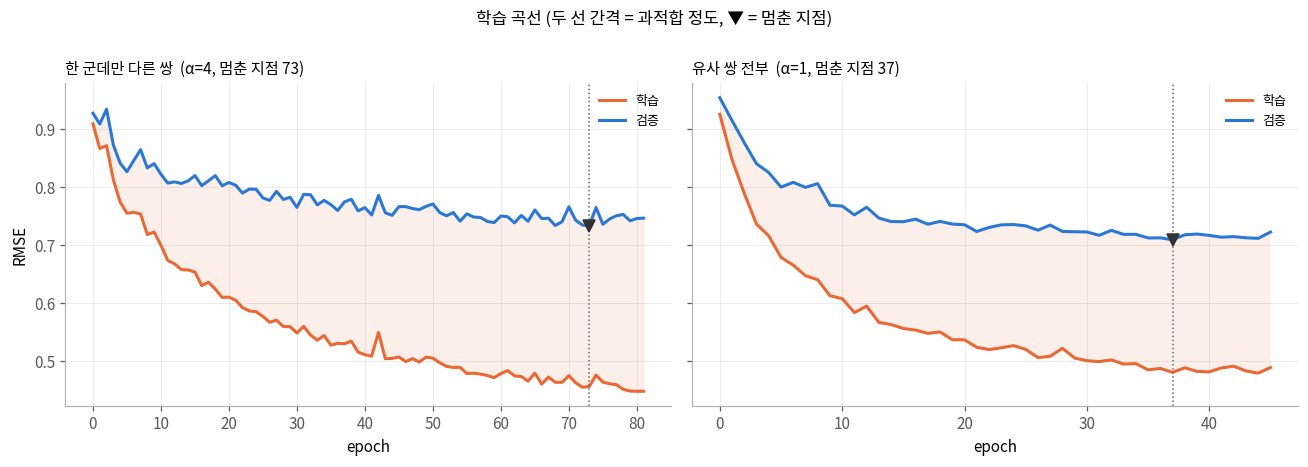

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for a_, st in zip(axes, RESULTS):
    h = pd.read_csv(f'{RUNS}/hist_a{BEST[st]}_{TAGS[st]}_seed{SEEDS[0]}.csv')
    stop = int(h.best_epoch[0])
    a_.plot(h.epoch, h.train, color=C2, lw=2, label='학습')
    a_.plot(h.epoch, h.val, color=C1, lw=2, label='검증')
    a_.fill_between(h.epoch, h.train, h.val, color=C2, alpha=0.10, lw=0)
    a_.axvline(stop, color='0.4', lw=1, ls=':')
    a_.plot([stop], [h.val.min()], marker='v', color='0.2', ms=8, clip_on=False)
    a_.set(xlabel='epoch')
    a_.set_title(f'{LABEL[st]}  (α={BEST[st]}, 멈춘 지점 {stop})', loc='left', fontsize=10)
    a_.legend(fontsize=8.5, frameon=False); tidy(a_)
axes[0].set_ylabel('RMSE')
fig.suptitle('학습 곡선 (두 선 간격 = 과적합 정도, ▼ = 멈춘 지점)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

### α에 따른 변화

α를 키우면 cliff는 좋아지고 non-cliff는 나빠진다. **왼쪽 아래가 좋다.**
점선 오른쪽은 "항상 0이라고 답하는 것"보다 못한 영역이다.

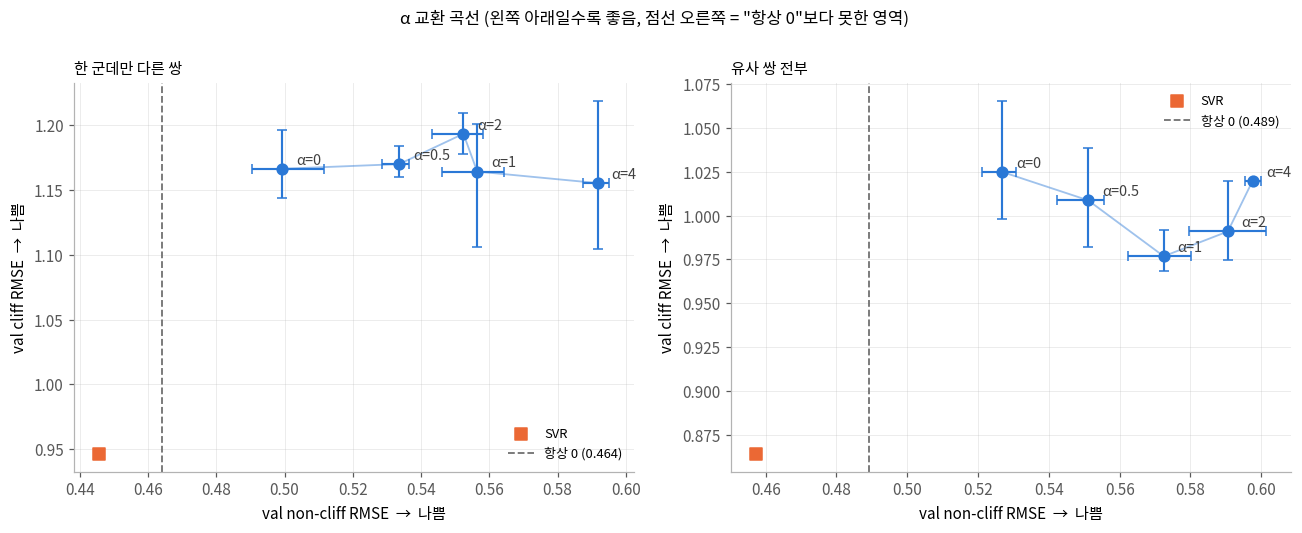

val cliff  val non-cliff  val all
           alpha                                   
한 군데만 다른 쌍 0          1.166          0.499    0.702
           0.5        1.170          0.534    0.723
           1          1.164          0.556    0.734
           2          1.193          0.552    0.742
           4          1.155          0.592    0.753
유사 쌍 전부    0          1.025          0.527    0.701
           0.5        1.009          0.551    0.707
           1          0.977          0.572    0.707
           2          0.991          0.591    0.723
           4          1.020          0.598    0.738

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for a_, (st, pset) in zip(axes, RESULTS.items()):
    v = pset[pset.split.str.startswith('val')]
    pts = []
    for a in ALPHAS:
        nc, cl = seed_rmse(v, a, ~v.is_cliff), seed_rmse(v, a, v.is_cliff)
        a_.errorbar(nc.mean(), cl.mean(),
                    xerr=[[nc.mean() - nc.min()], [nc.max() - nc.mean()]],
                    yerr=[[cl.mean() - cl.min()], [cl.max() - cl.mean()]],
                    fmt='o', ms=7, color=C1, ecolor=C1, elinewidth=1.4, capsize=3, zorder=3)
        a_.annotate(f'α={a}', (nc.mean(), cl.mean()), textcoords='offset points', xytext=(9, 3),
                    fontsize=9.5, color='0.25')
        pts.append((nc.mean(), cl.mean()))
    a_.plot(*zip(*sorted(pts)), color=C1, lw=1.2, alpha=.45, zorder=2)
    nm, cm = ~v.is_cliff, v.is_cliff
    a_.scatter([rmse(v[nm].pred_svr, v[nm].delta)], [rmse(v[cm].pred_svr, v[cm].delta)],
               marker='s', s=60, color=C2, zorder=4, label='SVR')
    z = rmse(v[nm].pred_zero, v[nm].delta)
    a_.axvline(z, color=MUTED, ls='--', lw=1.2, zorder=1, label=f'항상 0 ({z:.3f})')
    a_.set(xlabel='val non-cliff RMSE  →  나쁨', ylabel='val cliff RMSE  →  나쁨')
    a_.set_title(LABEL[st], loc='left', fontsize=10)
    a_.legend(fontsize=8.5, frameon=False); tidy(a_)
fig.suptitle('α 교환 곡선 (왼쪽 아래일수록 좋음, 점선 오른쪽 = "항상 0"보다 못한 영역)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()
display(pd.concat({LABEL[st]: t for st, t in ALPHA_TABLES.items()}).round(3))

### 타깃별 차이

타깃별로 평가 쌍 cliff 오차를 비교한다.

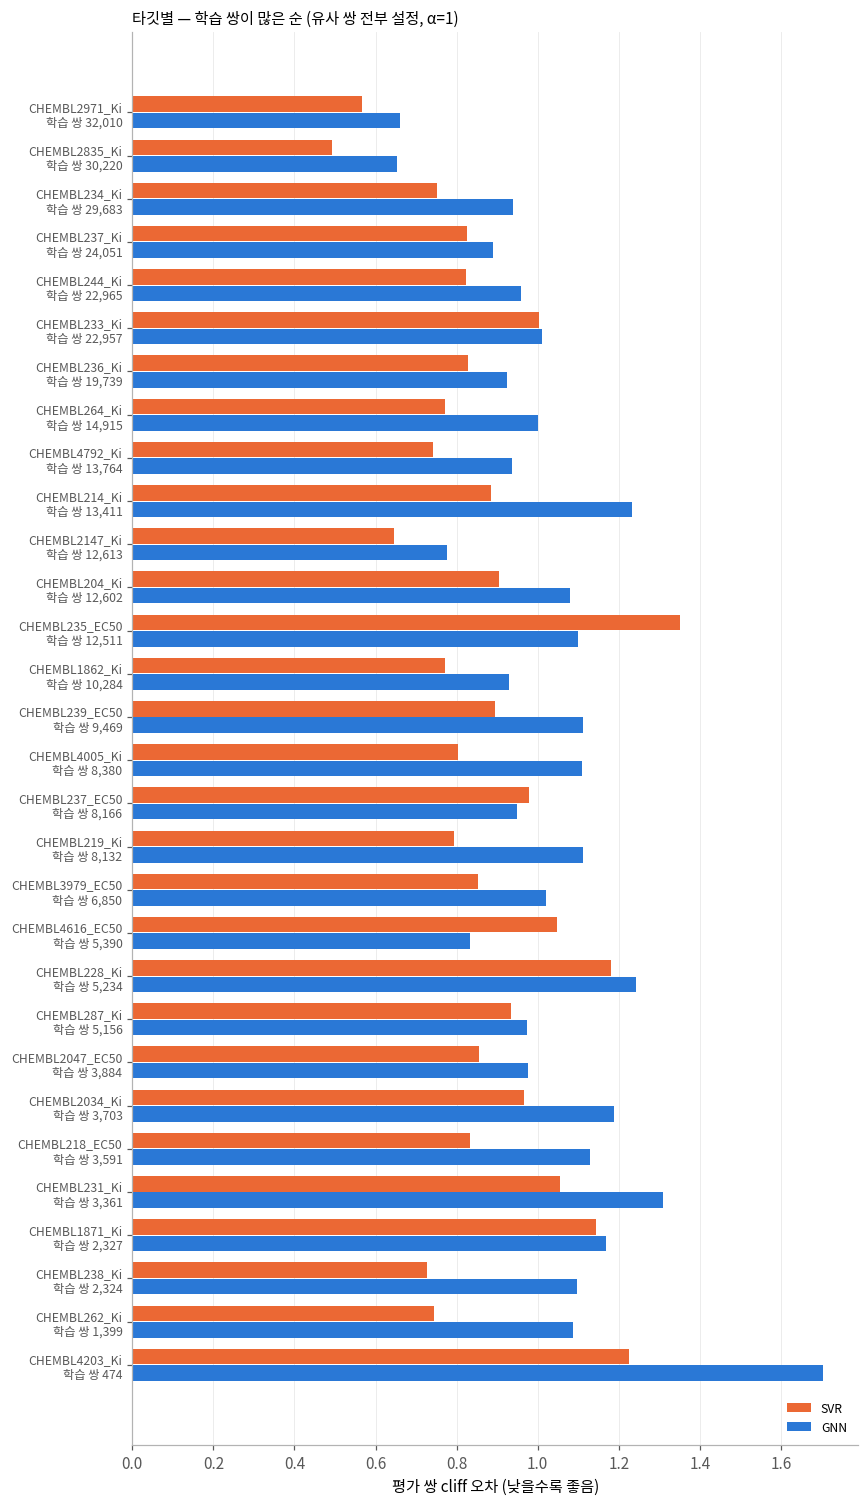

GNN이 SVR보다 나은 타깃: 3 / 30


In [35]:
pset = RESULTS['all']
tc = pset[(pset.split == 'test') & pset.is_cliff]
per = pd.DataFrame({m: {t: rmse(d[f'pred_{m}'], d.delta) for t, d in tc.groupby('target')}
                    for m in ['svr', 'gnn_best']})
per['n_train'] = pset[pset.split == 'train'].target.value_counts()
per = per.sort_values('n_train')

fig, a_ = plt.subplots(figsize=(8, max(3.6, 0.42 * len(per) + 1.2)))
y, hgt = np.arange(len(per)), 0.36
a_.barh(y + hgt / 2 * 1.06, per.svr, hgt, color=C2, label='SVR', zorder=2)
a_.barh(y - hgt / 2 * 1.06, per.gnn_best, hgt, color=C1, label='GNN', zorder=2)
a_.set(yticks=y, xlabel='평가 쌍 cliff 오차 (낮을수록 좋음)')
a_.set_yticklabels([f'{t}\n학습 쌍 {n:,}' for t, n in zip(per.index, per.n_train)], fontsize=8)
a_.legend(fontsize=8, frameon=False, loc='lower right'); a_.grid(axis='y', visible=False); tidy(a_)
a_.set_title(f'타깃별 — 학습 쌍이 많은 순 (유사 쌍 전부 설정, α={BEST["all"]})', loc='left', fontsize=10)
fig.tight_layout(); plt.show()
print(f'GNN이 SVR보다 나은 타깃: {int((per.gnn_best < per.svr).sum())} / {len(per)}')

### 차이 크기별 오차

약효 차이가 작은 쌍 / 중간 / 큰 쌍으로 나눠 오차를 본다.

In [36]:
BUCKETS = ['|Δ|<1', '1≤|Δ|<2', '|Δ|≥2']
MAES = {}
for st, pset in RESULTS.items():
    t_ = pset[pset.split.str.startswith('test')]
    b = pd.cut(t_.delta.abs(), [0, 1, 2, np.inf], right=False, labels=BUCKETS)
    m = pd.concat({k: t_.assign(b=b, ae=(t_[f'pred_{k}'] - t_.delta).abs())
                      .groupby(['split', 'b'], observed=True).ae.mean() for k in MODELS}, axis=1)
    m.insert(0, 'n', t_.assign(b=b).groupby(['split', 'b'], observed=True).size())
    MAES[st] = m

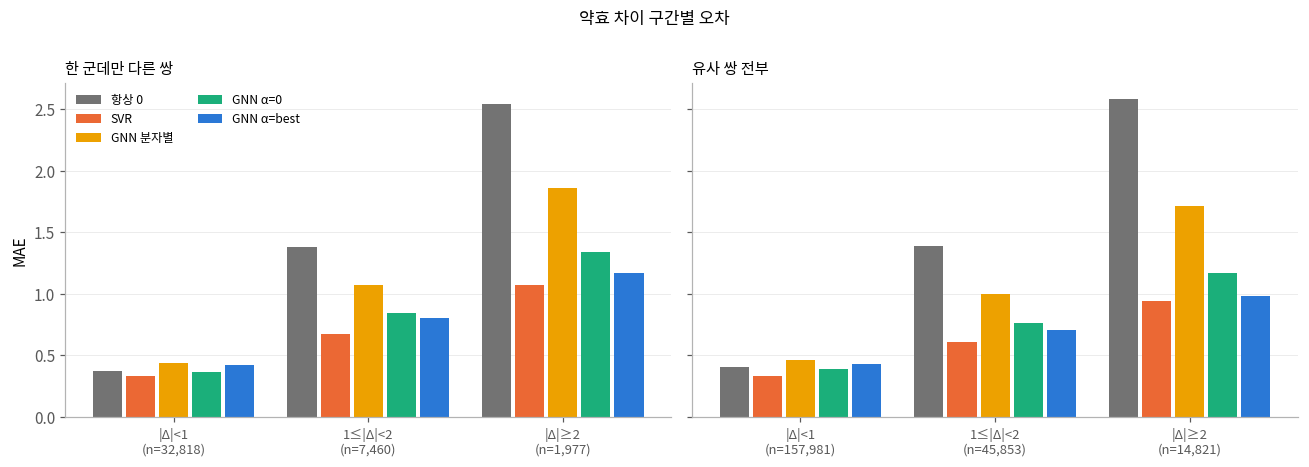

In [37]:
LBL = {'zero': '항상 0', 'svr': 'SVR', 'gnnmol': 'GNN 분자별', 'gnn_a0': 'GNN α=0', 'gnn_best': 'GNN α=best'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for a_, (st, mae) in zip(axes, MAES.items()):
    w = 0.17
    for i, (m, c) in enumerate(zip(MODELS, [MUTED, C2, C4, C3, C1])):
        v = [mae.loc[('test', b), m] for b in BUCKETS]
        a_.bar(np.arange(3) + (i - 2) * w, v, w * 0.88, color=c, label=LBL[m], zorder=2)
    a_.set(xticks=range(3))
    a_.set_xticklabels([f'{b}\n(n={int(mae.loc[("test", b), "n"]):,})' for b in BUCKETS], fontsize=8.5)
    a_.set_title(LABEL[st], loc='left', fontsize=10)
    a_.grid(axis='x', visible=False); tidy(a_)
axes[0].set_ylabel('MAE')
axes[0].legend(fontsize=8, frameon=False, ncol=2)
fig.suptitle('약효 차이 구간별 오차', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

### non-cliff에서 약한 이유

예측이 **실제보다 크게 나오는지** 본다. 차이가 거의 없는 쌍에도 큰 값을 말하면 오차가 커진다.
아래 숫자의 **기울기가 1보다 작으면 과장**이라는 뜻이다.

In [38]:
for st, pset in RESULTS.items():
    for sp in ['test']:
        d = pset[pset.split == sp]
        corr = float(np.corrcoef(d.pred_gnn_best, d.delta)[0, 1])
        slope = float(np.polyfit(d.pred_gnn_best, d.delta, 1)[0])
        print(f'{LABEL[st]:<10} {sp:<10} 상관 {corr:.3f}   기울기 {slope:.3f}')

    v = pset[pset.split.str.startswith('val')]
    c = float((v.delta * v.pred_gnn_best).sum() / (v.pred_gnn_best ** 2).sum())
    pset['pred_gnn_shrunk'] = c * pset.pred_gnn_best
    h = pset[pset.split == 'test']
    b0 = rmse(h[h.is_cliff].pred_gnn_best, h[h.is_cliff].delta), rmse(h[~h.is_cliff].pred_gnn_best, h[~h.is_cliff].delta)
    a0 = rmse(h[h.is_cliff].pred_gnn_shrunk, h[h.is_cliff].delta), rmse(h[~h.is_cliff].pred_gnn_shrunk, h[~h.is_cliff].delta)
    print(f'  → 전체를 {c:.3f}배로 줄이면 cliff {b0[0]:.3f}→{a0[0]:.3f}, non-cliff {b0[1]:.3f}→{a0[1]:.3f}\n')

한 군데만 다른 쌍 test       상관 0.642   기울기 0.783
  → 전체를 0.764배로 줄이면 cliff 1.091→1.159, non-cliff 0.565→0.492

유사 쌍 전부    test       상관 0.731   기울기 0.838


  → 전체를 0.856배로 줄이면 cliff 0.988→1.032, non-cliff 0.586→0.530



#### 아래 산점도 읽는 법

가로축 = **모델이 말한 차이**, 세로축 = **실제 차이**. 점 하나가 평가 쌍 하나다.

| 보이는 것 | 뜻 |
|---|---|
| 회색 대각선 | 완벽한 예측 — 점이 이 선 위면 말한 대로 맞은 것 |
| **검은 선** | 점들에 실제로 맞춘 직선 |
| **검은 선이 대각선보다 누움** | **말한 것보다 실제가 작다 = 차이를 과장한다** |
| 회색 세로 띠 | 모델이 "거의 안 변한다"고 답한 구간 |
| 파란 점 / 주황 점 | 실제로 cliff인 쌍 / 아닌 쌍 |

#### 이번 결과 해석

**두 그림 모두 검은 선이 대각선보다 눕는다 — 모델이 차이를 과장한다.**

| 평가 쌍 | 상관 | 기울기 | 모델이 "2"라고 하면 실제는 |
|---|---|---|---|
| 한 군데만 다른 쌍 | 0.64 | 0.78 | 약 1.6 |
| 유사 쌍 전부 | 0.73 | 0.84 | 약 1.7 |

**주황 점이 가로로 넓게 퍼진 것**이 핵심 문제다. 실제로는 차이가 거의 없는데(세로로 0 근처)
모델이 크게 말한(가로로 멀리) 쌍들이고, **이게 non-cliff 오차의 대부분**이다.

그렇다고 예측 전체를 상수배로 줄이면 진짜 cliff까지 같이 줄어든다 — 위 숫자가 그 결과다
(한 군데만 다른 쌍: 0.76배로 줄이면 non-cliff 0.565 → 0.492, cliff 1.091 → 1.159).

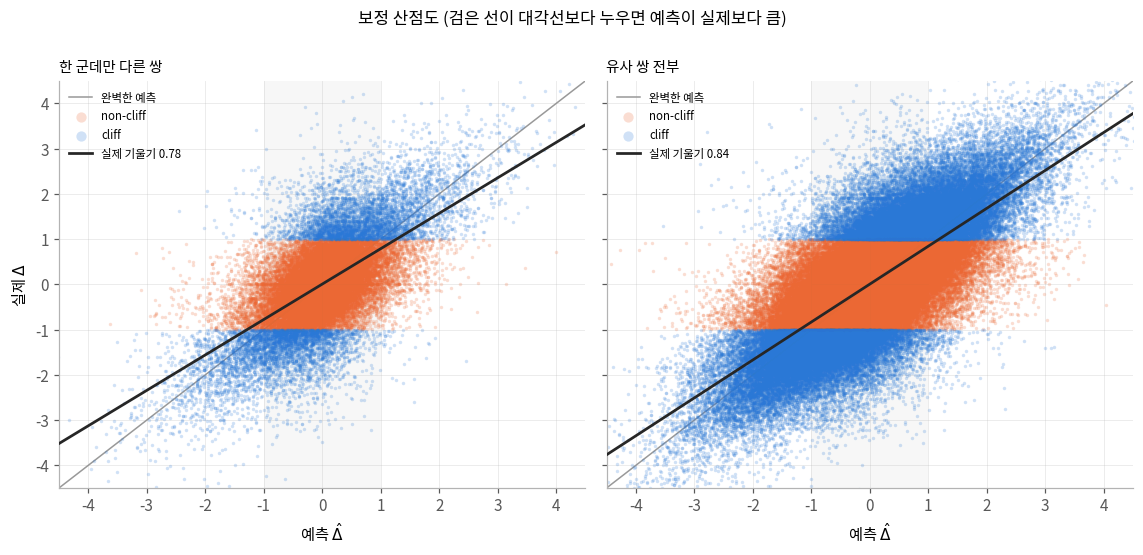

In [39]:
LIM = 4.5
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5), sharex=True, sharey=True)
for a_, (st, pset) in zip(axes, RESULTS.items()):
    d = pset[pset.split == 'test']
    a_.plot([-LIM, LIM], [-LIM, LIM], color='0.6', lw=1, zorder=1, label='완벽한 예측')
    for cl, c, lbl in [(False, C2, 'non-cliff'), (True, C1, 'cliff')]:
        m = (d.is_cliff == cl).values
        a_.scatter(d.pred_gnn_best[m], d.delta[m], s=5, alpha=0.22, color=c, lw=0, zorder=2, label=lbl)
    sl, ic = np.polyfit(d.pred_gnn_best, d.delta, 1)
    xs = np.array([-LIM, LIM])
    a_.plot(xs, sl * xs + ic, color='0.15', lw=1.8, zorder=3, label=f'실제 기울기 {sl:.2f}')
    a_.axvspan(-1, 1, color='0.5', alpha=0.06, lw=0, zorder=0)
    a_.set(xlim=(-LIM, LIM), ylim=(-LIM, LIM), xlabel=r'예측 $\hat{\Delta}$')
    a_.set_title(LABEL[st], loc='left', fontsize=9.5)
    a_.legend(fontsize=7.5, frameon=False, loc='upper left', markerscale=3)
    tidy(a_)
axes[0].set_ylabel(r'실제 $\Delta$')
fig.suptitle(r'보정 산점도 (검은 선이 대각선보다 누우면 예측이 실제보다 큼)', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

## 11. 결과 정리

**30개 타깃 · α 5가지 · 시드 3개.** 모든 쌍은 학습 분자를 하나 이상 포함한다(기준 분자 없는 쌍 제외).

| 설정 | 학습 쌍 | 평가 쌍 | 고른 α |
|---|---|---|---|
| 한 군데만 다른 쌍 | 67,509 | 42,255 | 4 |
| 유사 쌍 전부 | 349,565 | 218,655 | 1 |

### Δ 예측 (평가 쌍, 시드 3개 평균)

| | | 항상 0 | **SVR** | GNN 분자별 | GNN 쌍 α=0 | GNN 쌍 best |
|---|---|---|---|---|---|---|
| 한 군데만 | cliff | 1.720 | **0.928** | 1.397 | 1.134 | 1.091 |
| | non-cliff | 0.465 | **0.447** | 0.563 | 0.486 | 0.565 |
| 유사 쌍 전부 | cliff | 1.796 | **0.872** | 1.356 | 1.060 | 0.988 |
| | non-cliff | 0.490 | **0.459** | 0.591 | 0.521 | 0.586 |

### 알게 된 것
- **쌍으로 넣는 것은 도움이 된다.** 같은 GINE 인코더로 분자를 하나씩 예측해 빼면(분자별 GNN) 모든 칸에서 쌍 GNN보다 나쁘다
- **Δ만 맞추는 것이 아니다.** 실측 기준 분자 + Δ̂로 개별 활성을 추정하면 쌍 GNN 0.69 — 분자별 GNN(0.76)보다 낫다
- **그래도 SVR에 진다.** Δ 예측, 개별 활성 추정 모두. 분자 하나를 맞히는 오차부터 GNN 0.82 vs SVR 0.69다.
  약점은 쌍으로 푸는 방식이 아니라 **분자를 읽는 부분(GNN 표현)**에 있다
- **GNN은 비슷한 분자를 덜 일관되게 본다.** 기준 분자를 바꾸면 추정값이 SVR보다 3배 흔들리고(0.34 vs 0.10),
  차이를 과장한다(기울기 0.78). 그래서 non-cliff에서 "항상 0"보다도 못하다
- **누수가 GNN을 조금 도왔다.** 평가 분자의 1/3은 다른 타깃의 학습 분자였고, 처음 보는 분자에서는 SVR과의 격차가 더 크다
- **학습 데이터를 5배 늘린 효과는 작다** (같은 평가 쌍에서 비교 시 cliff 소폭 개선)

### 다음 할 일
1. **분류 후 예측** — 차이 구간(1 미만 / 1~2 / 2 이상)을 먼저 판단해, 1 미만이면 0으로 답한다
2. **GNN 표현 개선** — ECFP를 함께 넣기, 사전학습 인코더, 시드 앙상블로 예측을 매끄럽게
3. **조각 인코더 효과 측정** — 바뀐 부분을 따로 읽는 것이 실제로 도움이 되는지 빼고 학습해 비교
4. **3D 인코더 연결** — 분자 인코더 자리 교체